In [99]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import time
from collections import defaultdict
import statsmodels.api as sm
from statsmodels.genmod.families import links 
from statsmodels.api import Logit
import statsmodels.formula.api as smf
from statsmodels.formula.api import glm
from statsmodels.formula.api import ols
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings("ignore")

#prereq = "para trabajar pre req progv22025-09-15095342_procesado.xlsx"
#historial = "detalle matricula cohorte 2019.xlsx"
historial = "historia_todos.csv"
historial="historia_todos_2019_202610.parquet"

                                

## Helpers
### Asignaturas y metadatos
Funciones auxiliares para construir diccionarios y metadatos de asignaturas.

In [100]:
## Crear DataFrame con los nombres de las asignaturas y sus cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digos

def crear_df_asignaturas(df_historial: pd.DataFrame) -> pd.DataFrame:
    # Extraer las columnas relevantes
    df_asignaturas = df_historial[['Cod materia curso', 'Descripcion_Materia']].drop_duplicates()
    
    # Eliminar filas con valores nulos en 'Cod materia curso' o 'Descripcion_Materia'
    df_asignaturas = df_asignaturas.dropna(subset=['Cod materia curso', 'Descripcion_Materia'])
    
    # Eliminar espacios en blanco al inicio y al final de los nombres de las asignaturas
    df_asignaturas['Descripcion_Materia'] = df_asignaturas['Descripcion_Materia'].str.strip()
    
    # Eliminar duplicados basados en 'Cod materia curso', manteniendo la primera ocurrencia
    df_asignaturas = df_asignaturas.drop_duplicates(subset=['Cod materia curso'], keep='first')
    
    # Ordenar el DataFrame por 'Cod materia curso'
    df_asignaturas = df_asignaturas.sort_values(by='Cod materia curso').reset_index(drop=True)

    print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¹Ã…â€œÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ Creado DataFrame con las asignaturas unicas y sus nombres. NÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmero de asignaturas ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºnicas: {len(df_asignaturas)}")
    
    return df_asignaturas

In [101]:
## AÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±adir numero de intentos por asignatura

def calcular_num_intentos(df: pd.DataFrame) -> pd.DataFrame:
    # Paso 1: quedarse con intentos ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºnicos por periodo
    df_unique = df[['Pidm', 'Cod materia curso', 'Periodo']].drop_duplicates()

    # Paso 2: ordenar por periodo
    df_unique = df_unique.sort_values(['Pidm', 'Cod materia curso', 'Periodo'])

    # Paso 3: generar nÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmero de intento acumulado
    # rank(method='dense') da consecutivos (1,2,3..) por periodo distinto
    df_unique['num_intentos_asignatura'] = (
        df_unique.groupby(['Pidm', 'Cod materia curso']).cumcount() + 1
    )

    # Paso 4: hacer merge con el dataframe original
    df_result = df.merge(
        df_unique,
        on=['Pidm', 'Cod materia curso', 'Periodo'],
        how='left'
    )

    return df_result

In [102]:
import unicodedata
## Funciones de limpieza del DataFrame

def arreglar_comas_por_puntos(df: pd.DataFrame, cols_excluir: list) -> pd.DataFrame:
    """
    Reemplaza comas (,) por puntos (.) en todas las columnas tipo string,
    excepto en las columnas listadas en cols_excluir.
    Intenta convertir los valores resultantes a float.
    """
    for col in df.columns:
        if col not in cols_excluir and df[col].dtype == object:
            df[col] = df[col].str.replace(",", ".", regex=False)
            # Intentar conversiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n a float cuando sea posible
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass  # si no se puede convertir, se queda como string
            print(f"[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Procesada columna: {col}")
        elif col in cols_excluir:
            print(f"[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: {col}")
    return df


def imputar_valores(df: pd.DataFrame) -> pd.DataFrame:
    """Imputa/normaliza valores en columnas especificas."""

    def _norm_text(v):
        if pd.isna(v):
            return ""
        s = str(v).strip().lower()
        # Normaliza tildes y variantes para comparar categorias
        s = unicodedata.normalize("NFKD", s)
        s = "".join(ch for ch in s if not unicodedata.combining(ch))
        return s

    # Columna repitencia: vacios a 0.0
    col_repitencia = "_ Matricula detalle para analisis.repitencia profesor referencia"
    if col_repitencia in df.columns:
        antes = df[col_repitencia].isna().sum()
        df[col_repitencia] = df[col_repitencia].fillna(0).astype(float)
        print(f"[Imputacion] Columna '{col_repitencia}': {antes} vacios reemplazados por 0.0")

    # Columna Procedencia Categoria: "6 No registra" -> NaN
    col_procedencia = "_ Matricula detalle para analisis.Procedencia Categoria"
    if col_procedencia in df.columns:
        conteo = (df[col_procedencia] == "6 No registra").sum()
        df[col_procedencia] = df[col_procedencia].replace("6 No registra", np.nan)
        print(f"[Imputacion] Columna '{col_procedencia}': {conteo} valores '6 No registra' reemplazados por NaN")

    # Tipo colegio: combinar Colegio Bilingue/Biling?e e I en Institucion Privada
    col_tipo_colegio = "_ Matricula detalle para analisis.Tipo_Colegio"
    if col_tipo_colegio in df.columns:
        serie_norm = df[col_tipo_colegio].map(_norm_text)
        mask_tc = (serie_norm == "i") | (serie_norm.str.contains("biling", na=False))

        # Limpia etiquetas incorrectas previas y fija etiqueta final exacta
        mask_bad_priv = serie_norm.isin(["institucion privada", "instituci?n privada", "institucion  privada"])
        mask_tc = mask_tc | mask_bad_priv

        conteo_tc = int(mask_tc.sum())
        if conteo_tc > 0:
            df.loc[mask_tc, col_tipo_colegio] = "Institución Privada"

        print(
            f"[Imputacion] Columna '{col_tipo_colegio}': {conteo_tc} valores recodificados a 'Institución Privada'"
        )

    # Tipo calendario: combinar Calendario B e I en Calendario B
    col_tipo_cal = "_ Matricula detalle para analisis.Tipo_Calendario"
    if col_tipo_cal in df.columns:
        serie_tcal = df[col_tipo_cal].map(_norm_text)
        mask_tcal = serie_tcal.isin(["calendario b", "i"])
        conteo_tcal = int(mask_tcal.sum())
        if conteo_tcal > 0:
            df.loc[mask_tcal, col_tipo_cal] = "Calendario B"
        print(f"[Imputacion] Columna '{col_tipo_cal}': {conteo_tcal} valores ('Calendario B','I') -> 'Calendario B'")

    # Sexo: conservar solo M/F y eliminar filas con otros valores
    col_sexo = "_ Matricula detalle para analisis.Sexo"
    if col_sexo in df.columns:
        sexo_norm = df[col_sexo].astype(str).str.strip().str.upper()
        mask_valid_sexo = sexo_norm.isin(["M", "F"])
        filas_antes = len(df)
        df = df.loc[mask_valid_sexo].copy()
        filas_despues = len(df)
        eliminadas = filas_antes - filas_despues
        print(f"[Imputacion] Columna '{col_sexo}': eliminadas {eliminadas} filas por sexo invalido (solo M/F)")

    # Columna Calificacion_Final: vacios a -1
    col_nota_final = "Calificacion_Final"
    if col_nota_final in df.columns:
        conteo = df[col_nota_final].isna().sum()
        df[col_nota_final] = df[col_nota_final].fillna(-1).astype(float)
        print(f"[Imputacion] Columna '{col_nota_final}': {conteo} vacios reemplazados por -1")

    # Anadir columna de numero de intentos por asignatura
    df = calcular_num_intentos(df)
    print("[Imputacion] Columna 'num_intentos_asignatura': usando funcion calcular_num_intentos")

    return df

def eliminar_columnas_vacias(df: pd.DataFrame, columnas_eliminadas: list) -> pd.DataFrame:
    """Elimina columnas 100% vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­as."""
    cols_vacias = df.columns[df.isna().all()].tolist()
    if cols_vacias:
        df = df.drop(columns=cols_vacias)
        columnas_eliminadas.extend(cols_vacias)
        print(f"[Columnas] Eliminadas columnas vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­as: {cols_vacias}")
    else:
        print("[Columnas] No se encontraron columnas totalmente vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­as")
    return df


def eliminar_filas_por_columna(df: pd.DataFrame, col_usar: list) -> tuple[pd.DataFrame, list, int]:
    """
    Reglas de limpieza por completitud de columnas:
    - Si % nulos < 20%: elimina filas con nulos en esa columna.
    - Si completitud < 50% (equivale a >50% nulos): NO elimina filas,
      elimina esa columna de col_usar.
    """
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)
    col_usar_actual = col_usar.copy()
    columnas_removidas_col_usar = []
    columnas_removidas_df = []

    for col in df.columns:
        nulos = df[col].isna().sum()
        porcentaje_nulos = nulos / len(df) if len(df) > 0 else 0
        completitud = 1 - porcentaje_nulos

        if porcentaje_nulos == 0:
            continue

        # Nueva regla: baja completitud -> sacar de col_usar y del dataframe
        if completitud < 0.50:
            if col in col_usar_actual:
                col_usar_actual.remove(col)
                columnas_removidas_col_usar.append(col)
                print(f"[Completitud] Columna '{col}' con completitud {completitud:.2%} (<50%) -> eliminada de col_usar")
            else:
                print(f"[Completitud] Columna '{col}' con completitud {completitud:.2%} (<50%) -> no estaba en col_usar")

            columnas_removidas_df.append(col)
            print(f"[Completitud] Columna '{col}' removida del DataFrame por baja completitud")
            continue

        if porcentaje_nulos < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje_nulos:.2%} nulos -> eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje_nulos:.2%} de nulos (completitud {completitud:.2%}), no se eliminaron filas")

    if columnas_removidas_df:
        df = df.drop(columns=columnas_removidas_df, errors='ignore')

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} -> {filas_finales})")
    print(f"[Completitud] Columnas removidas de col_usar: {columnas_removidas_col_usar}")
    print(f"[Completitud] Columnas removidas del DataFrame: {columnas_removidas_df}")

    return df, col_usar_actual, filas_eliminadas_total

def eliminar_filas_por_columna_ignorando_col_prereq(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """
    Elimina filas con nulos en columnas con <20% vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­os,
    ignorando las columnas que siguen el patrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n Prereq_i_[Atributo].
    """
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        # Ignorar columnas de prerequisitos
        if col.startswith("Prereq_"):
            print(f"[Ignorado] Columna '{col}' pertenece a prerequisitos, no se revisa.")
            continue

        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje:.2%} nulos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¥20%), no se eliminaron filas")

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ {filas_finales})")

    return df, filas_eliminadas_total



def limpiar_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """FunciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n principal que limpia el dataframe segÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºn reglas definidas."""
    print("=== Iniciando limpieza del DataFrame ===")

    # ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n de valores
    df = imputar_valores(df)

    # Eliminar columnas vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­as
    columnas_eliminadas = []
    df = eliminar_columnas_vacias(df, columnas_eliminadas)

    # Eliminar filas segÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºn condiciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n por columnas
    #df, filas_eliminadas = eliminar_filas_por_columna(df)
    df, filas_eliminadas = eliminar_filas_por_columna_ignorando_col_prereq(df)
    
    # Resumen final
    print("\n=== Resumen limpieza ===")
    print(f"Filas eliminadas: {filas_eliminadas}")
    print(f"Columnas eliminadas: {columnas_eliminadas}")

    return df

In [103]:
#Renombrar Columnas

def renombrar_columnas(df: pd.DataFrame, tiene_prereq=True):
    """
    Renombra columnas largas por versiones cortas en snake_case.
    Devuelve:
      - DataFrame con columnas renombradas
      - Lista con columnas finales de anÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lisis (col_usar renombradas)
      - String con el nombre de la variable objetivo renombrada
    """

    # Mapeo de nombres originales a nuevos
    mapping = {
        "_ Matricula detalle para analisis.repitencia profesor referencia 1ano": "repitencia_prof_ref",
        "Nombre_Programa": "programa",
        "_ Matricula detalle para analisis.Prof_Codigo": "profesor_codigo",
        "_ Matricula detalle para analisis.pga inicial": "pga_inicial",
        "_ Matricula detalle para analisis.prom semestral t_1": "promedio_sem_t1",
        "_ Matricula detalle para analisis.Sexo": "sexo",
        "_ Matricula detalle para analisis.Asistencia CREE t_1": "asistencia_cree_t1",
        "_ Matricula detalle para analisis.Procedencia Categoria": "procedencia_categoria",
        "_ Matricula detalle para analisis.Edad cursan asignatura": "edad_curso",
        "_ Matricula detalle para analisis.Calif Final _ Retiros": "resultado_final",
        "_ Matricula detalle para analisis.Puntaje estrato" : "estrato",
        "_ Matricula detalle para analisis.Puntaje_icfes_recalificado" : "puntaje_saber11",
        "_ Matricula detalle para analisis.Dif anios icfes clase" : "aÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±os_saber11_vs_clase",
        "_ Matricula detalle para analisis.PCN_Puntaje_Ciencias_Naturales" : "saber11_Ciencias_Naturales",
        "_ Matricula detalle para analisis.PIN_Puntaje_en_Ingles": "saber11_ingles",
        "_ Matricula detalle para analisis.PLC_Puntaje_para_Lectura_Critica": "saber11_lectura_critica",
        "_ Matricula detalle para analisis.PMA_Puntaje_para_Matematicas": "saber11_matematicas",
        "_ Matricula detalle para analisis.PSC_Puntaje_Sociales_y_Ciudadanas": "saber11_sociales",
        "_ Matricula detalle para analisis.Tipo_Colegio": "Tipo_colegio",
        "_ Matricula detalle para analisis.Tipo_Calendario": "Tipo_calendario"
    }

      # Renombrar columnas
    df = df.rename(columns=mapping)

    if tiene_prereq:
    # Construir lista final de columnas de anÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lisis
        col_usar = [
            "repitencia_prof_ref",
            "programa",
            "profesor_codigo",
            "pga_inicial",
            "promedio_sem_t1",
            "sexo",
            "asistencia_cree_t1",
            "procedencia_categoria",
            "edad_curso",
            "num_intentos_asignatura",
            #"num_semestres_profesor_asignatura",
            "estrato"
            #,"Tipo_colegio","Tipo_calendario"
        ]
    else:
        df,col_usar=check_columnas_no_prereq_pga(df)


    # Variable objetivo
    var_objetivo = "resultado_final"

    return df, col_usar, var_objetivo

def check_columnas_no_prereq_pga(df: pd.DataFrame):
    """
    Verifica si el DataFrame contiene columnas de prerequisitos.
    Retorna True si existen columnas que comienzan con 'Prereq_', False en caso contrario.
    """
    cols_usar=["repitencia_prof_ref",
            "programa",
            "profesor_codigo",
            "sexo",
            "asistencia_cree_t1",
            "procedencia_categoria",
            "edad_curso",
            "num_intentos_asignatura",
            #"num_semestres_profesor_asignatura",
            "estrato", "Tipo_colegio", "Tipo_calendario"]
    
    cols_pga_solo=["pga_inicial"]
    
    cols_pga=["pga_inicial", "promedio_sem_t1"]

    cols_icfes_total = ["puntaje_saber11",
        "aÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±os_saber11_vs_clase",
        "saber11_Ciencias_Naturales",
        "saber11_ingles",
        "saber11_lectura_critica",
        "saber11_matematicas",
        "saber11_sociales",
    ]

    cols_icfes_sin_pj_general = [ "aÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±os_saber11_vs_clase",
        "saber11_Ciencias_Naturales",
        "saber11_ingles",
        "saber11_lectura_critica",
        "saber11_matematicas",
        "saber11_sociales"
    ]
    col_puntje_icfes ="puntaje_saber11"
    
    # Verificar existencia y completitud de la columna pga_inicial
    if "pga_inicial" not in df.columns:
        print("No se encontrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ la columna 'pga_inicial'")
        return df, cols_usar

    total = len(df)
    if total == 0:
        print("DataFrame vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­o")
        return df, cols_usar

    nulos = df["pga_inicial"].isna().sum()
    porcentaje_nulos = nulos / total

    # Evaluar segÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºn umbrales
    if porcentaje_nulos > 0.80:
        cols_usar= cols_usar+cols_icfes_total
        print("[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Mas del 80% de los datos no tiene PGA usando las variables del icfes y colegio")
    elif abs(porcentaje_nulos > 0.30) :  
        print("[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Usar imputacion de ICFES imputar")
        # Intentar imputar pga_inicial usando '_ Matricula detalle para analisis.Puntaje_icfes_recalificado'
        if col_puntje_icfes not in df.columns:
            print(f"[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] No se encuentra la columna '{col_puntje_icfes}', se usarÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡n variables del ICFES por defecto")
            cols_usar = cols_usar + cols_icfes_total
        else:
            # convertir a numÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©rico y trabajar sÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³lo con los valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos para min-max
            icfes_ser = pd.to_numeric(df[col_puntje_icfes], errors='coerce')
            icfes_valid = icfes_ser.dropna()

            if icfes_valid.empty or icfes_valid.max() == icfes_valid.min():
                print(f"[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Imposible normalizar '{col_puntje_icfes}' (valores insuficientes o constantes). Se usan variables ICFES")
                cols_usar = cols_usar + cols_icfes_total
            else:
                min_v = icfes_valid.min()
                max_v = icfes_valid.max()
                # normalizar a [0,1] y escalar a [0,5]
                icfes_scaled = (icfes_ser - min_v) / (max_v - min_v) * 5

                # rellenar sÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³lo donde pga_inicial es nulo
                n_nulos_before = df["pga_inicial"].isna().sum()
                mask_fill = df["pga_inicial"].isna() & icfes_scaled.notna()
                df.loc[mask_fill, "pga_inicial"] = icfes_scaled.loc[mask_fill].astype(float)
                df["pga_inicial"] = df["pga_inicial"].astype(float)

                n_filled = mask_fill.sum()
                print(f"[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'pga_inicial': {n_filled} valores imputados usando '{col_puntje_icfes}' (min={min_v}, max={max_v})")

                # Imputar 'promedio_sem_t1' de la misma forma usando icfes_scaled (si existe)
                if "promedio_sem_t1" in df.columns:
                    mask_fill_prom = df["promedio_sem_t1"].isna() & icfes_scaled.notna()
                    df.loc[mask_fill_prom, "promedio_sem_t1"] = icfes_scaled.loc[mask_fill_prom].astype(float)
                    # Asegurar tipo float
                    df["promedio_sem_t1"] = df["promedio_sem_t1"].astype(float)
                    n_filled_prom = mask_fill_prom.sum()
                    print(f"[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'promedio_sem_t1': {n_filled_prom} valores imputados usando '{col_puntje_icfes}' (mismo escalado)")
                else:
                    print("[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'promedio_sem_t1' no encontrada, no se imputÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³")

                # ahora podemos usar las columnas pga
                cols_usar = cols_usar + cols_pga_solo + cols_icfes_sin_pj_general
    else:
        cols_usar = cols_usar + cols_pga
        print("[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Usar PGA")
      

    return df, cols_usar



In [104]:
## Indentificar columnas de prerequisitos vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidas

## Indentificar columnas de prerequisitos vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidas

def columnas_prereq_validas(df: pd.DataFrame, umbral: float = 0.8) -> list:
    """
    Identifica las columnas de prerequisitos (Nota e Intentos) que cumplen con tener
    al menos un 80% de valores no nulos en la columna Nota.
    
    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        df: DataFrame de entrada
        umbral: proporciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­nima de valores no nulos (default=0.8)
    
    Retorna:
        lista con las columnas Prereq_i_Nota y Prereq_i_Intentos que cumplen el criterio.
    """
    columnas_seleccionadas = []
    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")

        if col_intentos not in df.columns:
            print(f"[Aviso] No se encontrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ la columna de intentos para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            columnas_seleccionadas.extend([col_nota, col_intentos])
            print(f"[Incluido] {col_nota} y {col_intentos} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ {proporcion:.2%} valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos")
        else:
            print(f"[Excluido] {col_nota} y {col_intentos} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ {proporcion:.2%} valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<{umbral:.0%})")

    print("\nResumen final:")
    print(f"Columnas seleccionadas: {columnas_seleccionadas}")

    return columnas_seleccionadas

## Identificar columnas de prerequisitos vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidas (versiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n 2) Con cambio de nombre!

import unicodedata


def normalizar_nombre(nombre: str) -> str:
    """
    Convierte un nombre en snake_case sin acentos, dejando los nÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmeros intactos.
    """
    # Eliminar acentos
    nombre = ''.join(
        c for c in unicodedata.normalize('NFD', nombre)
        if unicodedata.category(c) != 'Mn'
    )
    # Reemplazar espacios y caracteres raros por "_", pero dejar letras y nÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmeros
    nombre = re.sub(r'[^a-zA-Z0-9]+', '_', nombre)
    # Pasar a minÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºsculas
    nombre = nombre.strip("_").lower()
    return nombre

def columnas_prereq_validas_ext(df: pd.DataFrame, nombres_asignaturas: pd.DataFrame, umbral: float = 0.8):
    """
    Identifica columnas de prerequisitos que cumplen con el umbral de no-nulos
    y crea nuevas columnas con el nombre de la asignatura.

    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        df: DataFrame de entrada (con columnas Prereq_i_Nota y Prereq_i_Codigo)
        nombres_asignaturas: DataFrame con columnas ["Cod materia curso", "Descripcion_Materia"]
        umbral: proporciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­nima de valores no nulos en la columna Nota (default=0.8)

    Retorna:
        columnas_nuevas (list): Lista con los nombres de las nuevas columnas creadas
        df_modificado (pd.DataFrame): DataFrame con las columnas nuevas aÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±adidas
    """
    columnas_nuevas = []
    df_modificado = df.copy()

    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")
        col_codigo = col_nota.replace("_Nota", "_Codigo")

        if col_intentos not in df.columns:
            print(f"[Aviso] No se encontrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ la columna de intentos para {col_nota}, se omite el par.")
            continue
        if col_codigo not in df.columns:
            print(f"[Aviso] No se encontrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ la columna de cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            # Procesar cada fila: buscar nombre de la materia
            nuevas_columnas_temp = []
            for idx, codigo in df.loc[df[col_codigo].notna(), col_codigo].items():
                # Buscar en nombres_asignaturas
                nombre_match = nombres_asignaturas.loc[
                    nombres_asignaturas["Cod materia curso"] == codigo, 
                    "Descripcion_Materia"
                ]
                if not nombre_match.empty:
                    nombre_materia = nombre_match.values[0]
                else:
                    nombre_materia = codigo  # fallback

                # Normalizar nombre
                nombre_materia_norm = normalizar_nombre(str(nombre_materia))
                nueva_columna = f"Prereq_{nombre_materia_norm}_Nota"

                # Crear la columna si no existe
                if nueva_columna not in df_modificado.columns:
                    df_modificado[nueva_columna] = pd.NA

                # Asignar el valor de la nota, asegurando tipo float
                valor_nota = df.loc[idx, col_nota]
                try:
                    valor_nota_float = float(valor_nota)
                except (ValueError, TypeError):
                    valor_nota_float = pd.NA
                df_modificado.at[idx, nueva_columna] = valor_nota_float

                # Forzar tipo float en la columna creada (puede tener <NA>)
                df_modificado[nueva_columna] = pd.to_numeric(df_modificado[nueva_columna], errors='coerce')

                nuevas_columnas_temp.append(nueva_columna)

                # AÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±adir columna de numero de intentos asociados
                nueva_columna_intentos = f"Prereq_{nombre_materia_norm}_Intentos"
                if nueva_columna_intentos not in df_modificado.columns:
                    df_modificado[nueva_columna_intentos] = pd.NA

                valor_intentos = df.loc[idx, col_intentos]
                try:
                    valor_intentos_float = float(valor_intentos)
                except (ValueError, TypeError):
                    valor_intentos_float = pd.NA
                df_modificado.at[idx, nueva_columna_intentos] = valor_intentos_float

                # Forzar tipo int en la columna de intentos (puede tener <NA>)
                df_modificado[nueva_columna_intentos] = pd.to_numeric(df_modificado[nueva_columna_intentos], errors='coerce')
                
                nuevas_columnas_temp.append(nueva_columna_intentos)

            # Agregar solo las columnas ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºnicas de esta ronda
            columnas_nuevas.extend(list(set(nuevas_columnas_temp)))

            print(f"[Incluido] {col_nota} y {col_intentos} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ {proporcion:.2%} vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.")
        else:
            print(f"[Excluido] {col_nota} y {col_intentos} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ {proporcion:.2%} vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<{umbral:.0%})")

    print("\nResumen final:")
    print(f"Columnas nuevas seleccionadas: {columnas_nuevas}")

    return columnas_nuevas, df_modificado



##La diferencia entre esta funcion y la atenrior es que esta tiene en cuenta que pueden venir diferentes asiganturas en las opciones de prerwequisito
import pandas as pd

def columnas_prereq_validas_ext_dif_prereq(
    df: pd.DataFrame,
    nombres_asignaturas: pd.DataFrame,
    umbral: float = 0.8,            # umbral sobre Prereq_i_Nota (columna fuente)
    umbral_pareja: float = 0.90     # umbral por par de columnas creadas (nota+intentos)
):
    """
    Identifica columnas de prerequisitos que cumplen con el umbral de no-nulos
    y crea nuevas columnas por cada CÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“DIGO distinto, con el nombre de la asignatura
    (o el cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo si no hay match). Cada cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo genera un par:
        Prereq_<nombre_norm>_Nota
        Prereq_<nombre_norm>_Intentos

    Reglas adicionales:
      - Si para un cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo hay mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºltiples descripciones en 'nombres_asignaturas', se toma la primera.
      - Tras crear el par, si su completitud relativa es < umbral_pareja, se eliminan ambas columnas
        y no se reportan en la salida.

    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        df: DataFrame de entrada con columnas Prereq_i_Nota, Prereq_i_Codigo, Prereq_i_Intentos
        nombres_asignaturas: DataFrame con ["Cod materia curso", "Descripcion_Materia"]
        umbral: proporciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­nima de valores no nulos en la columna fuente Prereq_i_Nota (default=0.8)
        umbral_pareja: proporciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­nima (>=0.90) del par nuevo respecto a no-nulos de Prereq_i_Nota

    Retorna:
        columnas_nuevas (list): nombres de columnas finalmente creadas (y que superaron el umbral_pareja)
        df_modificado (pd.DataFrame): DataFrame con las columnas nuevas aÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â±adidas
    """
    columnas_nuevas = []
    df_modificado = df.copy()

    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")
        col_codigo = col_nota.replace("_Nota", "_Codigo")

        if col_intentos not in df.columns:
            print(f"[Aviso] No se encontrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ la columna de intentos para {col_nota}, se omite el trÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­o.")
            continue
        if col_codigo not in df.columns:
            print(f"[Aviso] No se encontrÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³ la columna de cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo para {col_nota}, se omite el trÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­o.")
            continue

        total = len(df_modificado)
        no_nulos_fuente = df_modificado[col_nota].notna().sum()
        proporcion_fuente = (no_nulos_fuente / total) if total > 0 else 0.0

        if proporcion_fuente < umbral:
            print(f"[Excluido] {col_nota} (y su par {col_intentos}) ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ {proporcion_fuente:.2%} vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<{umbral:.0%})")
            continue

        # --- Paso 1: identificar cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digos distintos en este prereq_i ---
        codigos_validos = df_modificado.loc[df_modificado[col_codigo].notna(), col_codigo].unique().tolist()

        # Guardar columnas creadas en esta ronda para posible limpieza por umbral_pareja
        columnas_creadas_ronda = []  # lista de pares (nota_col, intentos_col)

        # --- Paso 2: crear/llenar columnas por CÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“DIGO ---
        for codigo in codigos_validos:
            # Buscar nombre (tomar primera coincidencia) o usar el propio cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo
            match = nombres_asignaturas.loc[
                nombres_asignaturas["Cod materia curso"] == codigo,
                "Descripcion_Materia"
            ]
            if not match.empty:
                nombre_materia = match.values[0]
            else:
                nombre_materia = codigo  # fallback

            # Normalizar nombre
            nombre_materia_norm = normalizar_nombre(str(nombre_materia))

            nueva_col_nota = f"Prereq_{nombre_materia_norm}_Nota"
            nueva_col_int = f"Prereq_{nombre_materia_norm}_Intentos"

            # Crear columnas si no existen
            if nueva_col_nota not in df_modificado.columns:
                df_modificado[nueva_col_nota] = pd.NA
            if nueva_col_int not in df_modificado.columns:
                df_modificado[nueva_col_int] = pd.NA

            # Filas donde este cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo aplica en este prereq
            mask_codigo = df_modificado[col_codigo] == codigo

            # Asignar valores sÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³lo en las filas donde corresponde el cÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³digo
            # Nota
            valores_nota = pd.to_numeric(df_modificado.loc[mask_codigo, col_nota], errors="coerce")
            df_modificado.loc[mask_codigo, nueva_col_nota] = valores_nota

            # Intentos
            valores_intentos = pd.to_numeric(df_modificado.loc[mask_codigo, col_intentos], errors="coerce")
            df_modificado.loc[mask_codigo, nueva_col_int] = valores_intentos

            # Forzar tipo numÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©rico (permitiendo NaN)
            df_modificado[nueva_col_nota] = pd.to_numeric(df_modificado[nueva_col_nota], errors="coerce")
            df_modificado[nueva_col_int] = pd.to_numeric(df_modificado[nueva_col_int], errors="coerce")

            columnas_creadas_ronda.append((nueva_col_nota, nueva_col_int))

        # --- Paso 3: filtrar por completitud relativa (umbral_pareja) y limpiar pares que no cumplan ---
        # Denominador: no_nulos_fuente (Prerreq_i_Nota) ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ filas donde hubo dato en la fuente de este prereq
        if no_nulos_fuente == 0:
            # Nada que evaluar en esta ronda, pasar
            continue

        for nueva_col_nota, nueva_col_int in columnas_creadas_ronda:
            n_no_nulos_par = df_modificado[nueva_col_nota].notna().sum()
            completitud_relativa = n_no_nulos_par / no_nulos_fuente

            if completitud_relativa >= umbral_pareja:
                # Mantener y reportar
                columnas_nuevas.extend([nueva_col_nota, nueva_col_int])
                print(f"[Incluido] {nueva_col_nota} / {nueva_col_int} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ "
                      f"{completitud_relativa:.2%} de {col_nota} (>= {umbral_pareja:.0%})")
            else:
                # Eliminar ambas columnas (par) y NO reportarlas
                df_modificado.drop(columns=[nueva_col_nota, nueva_col_int], inplace=True, errors="ignore")
                print(f"[Excluido] {nueva_col_nota} / {nueva_col_int} ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ "
                      f"{completitud_relativa:.2%} de {col_nota} (< {umbral_pareja:.0%})")

    # Dejar ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºnicas y mantener orden de apariciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n
    seen = set()
    columnas_nuevas = [c for c in columnas_nuevas if not (c in seen or seen.add(c))]

    print("\nResumen final:")
    print(f"Columnas nuevas seleccionadas ({len(columnas_nuevas)}): {columnas_nuevas}")

    return columnas_nuevas, df_modificado





In [105]:
## ONE HOT

import random

def aplicar_one_hot(df: pd.DataFrame, cols: list, drop_random: bool = True, umbral_eliminar: float = 0.10) -> tuple[pd.DataFrame, list]:
    """
    Aplica one-hot encoding sobre columnas especificas y devuelve:
    - DataFrame transformado
    - Lista de columnas dummy validas para modelado
    """
    df = df.copy()
    nuevas_columnas = []

    cols_presentes = [c for c in cols if c in df.columns]
    cols_faltantes = [c for c in cols if c not in df.columns]

    if cols_faltantes:
        print(f"[Aviso] Columnas no encontradas para OneHot (se omiten): {cols_faltantes}")

    for col in cols_presentes:
        dummies = pd.get_dummies(df[col], prefix=col, dummy_na=False).astype(int)

        if dummies.shape[1] == 0:
            print(f"[OneHot] Columna '{col}' no genero dummies, se omite.")
            df = df.drop(columns=[col])
            continue

        if drop_random and len(dummies.columns) > 1:
            col_drop = random.choice(dummies.columns.tolist())
            dummies = dummies.drop(columns=[col_drop])
            print(f"[OneHot] Columna '{col}' -> eliminada aleatoriamente '{col_drop}' para evitar multicolinealidad")

        df = df.drop(columns=[col]).join(dummies)

        cols_validas = []
        for dummy in dummies.columns:
            proporcion = dummies[dummy].sum() / len(dummies)
            if proporcion >= umbral_eliminar:
            #if proporcion >= 0.10:
                cols_validas.append(dummy)
            else:
                print(f"[Filtro] Columna '{dummy}' no incluida en la lista (solo {proporcion:.2%} en 1s)")

        nuevas_columnas.extend(cols_validas)
        print(f"[OneHot] Columna '{col}' -> creadas {len(dummies.columns)} columnas, validas: {cols_validas}")

    return df, nuevas_columnas

In [106]:
#Cambiar a category

def cambiar_a_category(df, cols):
    # Convierte columnas a category si existen

    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype("category")
        else:
            print(f"Columna no encontrada: {c}")

    # Verificar tipos resultantes
    print(df[ [c for c in cols if c in df.columns] ].dtypes)  

    return df


    

In [107]:
# Entrenar_xgboost_regresion

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

def entrenar_xgboost_regresion(df, columna_objetivo, columnas_predictores):
    """
    Entrena un modelo XGBoost de regresiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n sobre un dataframe.

    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        df (pd.DataFrame): DataFrame con los datos
        columna_objetivo (str): Nombre de la columna a predecir
        columnas_predictores (list): Lista con nombres de columnas de entrada

    Retorna:
        modelo (XGBRegressor): Modelo entrenado
        df_resultados (pd.DataFrame): DataFrame original con columna de predicciones
        metricas (dict): RMSE, MAE, R2
    """

    # Separar variables
    X = df[columnas_predictores]
    y = df[columna_objetivo]

    # Dividir en train (80%) y test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Definir modelo
    modelo = XGBRegressor(
        objective="reg:squarederror",
        enable_categorical=True,
        random_state=42
    )

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predicciones en test
    y_pred = modelo.predict(X_test)

    # Calcular mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©tricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R2": r2}

    # Mostrar mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©tricas como tabla
    print("\nÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â  MÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©tricas de evaluaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n del modelo:\n")
    print(pd.DataFrame(metricas, index=["Valores"]).T)

    # Agregar columna de predicciones al df
    df_resultados = df.copy()
    df_resultados["Prediccion_XGB"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test


In [108]:
# mostrar_arbol & mostrar_importancia_gain & reporte_importancia

from xgboost import plot_tree
import matplotlib.pyplot as plt
from xgboost import plot_importance

def mostrar_arbol(modelo, num_tree=0, ancho=40, alto=20, orientacion="LR"):
    """
    Muestra el ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡rbol de decisiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n generado por XGBoost.

    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        modelo (XGBRegressor): Modelo entrenado
        num_tree (int): ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Ândice del ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡rbol a graficar
        ancho (int): Ancho de la figura
        alto (int): Alto de la figura
        orientacion (str): DirecciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n del ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡rbol ("LR"=izq-der, "TB"=arriba-abajo)
    """
    plt.figure(figsize=(ancho, alto))
    plot_tree(modelo, num_trees=num_tree, rankdir=orientacion)
    plt.show()


def mostrar_importancia_gain(modelo, top_n=20):
    """
    Muestra la importancia de las variables en el modelo.
    
    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        modelo (XGBRegressor): Modelo entrenado
        top_n (int): NÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmero de variables a mostrar
    """
    plt.figure(figsize=(10,6))
    plot_importance(modelo, importance_type="gain", max_num_features=top_n, height=0.5)
    plt.title("Importancia de variables (gain)")
    plt.show()


def reporte_importancia(modelo):
    """
    Genera un reporte tabulado de importancia de variables
    con mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©tricas: gain, weight y cover.
    """
    booster = modelo.get_booster()

    # Obtener cada mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©trica como diccionario
    importancia_gain = booster.get_score(importance_type="gain")
    importancia_weight = booster.get_score(importance_type="weight")
    importancia_cover = booster.get_score(importance_type="cover")

    # Convertir a DataFrame
    df_gain = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    df_weight = pd.DataFrame.from_dict(importancia_weight, orient="index", columns=["Weight"])
    df_cover = pd.DataFrame.from_dict(importancia_cover, orient="index", columns=["Cover"])

    # Unir todo
    df_importancia = df_gain.join(df_weight).join(df_cover)

    # Ordenar por Gain
    df_importancia = df_importancia.sort_values("Gain", ascending=False)

    print("\nÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â  Reporte de Importancia de Variables (XGBoost)\n")
    print(df_importancia)

    return df_importancia


In [109]:
#matriz_confusion

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def matriz_confusion_personalizada(df, columna_objetivo, columna_prediccion, margen_error=0.2, graficar=True):
    """
    Construye una matriz de confusiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n personalizada basada en un margen de error.

    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        df (pd.DataFrame): DataFrame con columna real y predicciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n
        columna_objetivo (str): Nombre de la columna real
        columna_prediccion (str): Nombre de la columna de predicciones
        margen_error (float): Margen permitido para considerar la predicciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n correcta
        graficar (bool): Si True, muestra la matriz de confusiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n en grÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡fico

    Retorna:
        matriz (np.ndarray): Matriz de confusiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n
        df_resultados (pd.DataFrame): DataFrame con columna de ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©xito (1 o 0)
    """

    # Copiar para no alterar el original
    df_resultados = df.copy()

    # Redondear predicciones a 2 decimales
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].round(2)

    # Convertir cualquier valor < 0 en -1
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].apply(lambda x: -1 if x < 0 else x)

    # Crear etiqueta de ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©xito: 1 si la diferencia es <= margen_error
    df_resultados["Exito"] = np.where(
        abs(df_resultados[columna_objetivo] - df_resultados[columna_prediccion]) <= margen_error, 
        1, 
        0
    )

    # Etiqueta real: siempre 1 (correcto) porque evaluamos predicciones
    # AquÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­ podemos definir "ground truth" como si el valor real fuera siempre vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lido
    # entonces comparamos con ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â©xito/fallo de predicciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n
    y_true = np.ones(len(df_resultados))   # todos deberÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­an ser "correctos"
    y_pred = df_resultados["Exito"]

    # Calcular matriz de confusiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n
    matriz = confusion_matrix(y_true, y_pred, labels=[1,0])
    print(classification_report(y_true, y_pred))

    if graficar:
        disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â°xito", "Fallo"])
        disp.plot(cmap="Blues")
        plt.title("Matriz de ConfusiÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n Personalizada")
        plt.show()

    return matriz, df_resultados


In [110]:
#shap

import shap 

def interpretar_xgboost_shap(modelo, X, columnas_predictores, top_n=5, id_check=0):
    """
    Genera interpretaciones SHAP para un modelo XGBoost:
    - Summary plot (impacto global de las variables)
    - Dependence plots para las N variables mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡s importantes

    ParÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡metros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        columnas_predictores (list): lista con nombres de variables
        top_n (int): nÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmero de variables mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡s importantes a mostrar en dependence plots
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    # --- 1. Summary plot ---
    print("ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â  Generando summary plot global...")
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores)

    # --- 2. Dependence plots ---
    print(f"\nÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â  Generando dependence plots para las {top_n} variables mÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡s importantes...\n")
    
    # Obtener importancia (gain) desde XGBoost
    importancia_gain = modelo.get_booster().get_score(importance_type="gain")
    importancia_df = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    importancia_df = importancia_df.sort_values("Gain", ascending=False).head(top_n)

    for feature in importancia_df.index:
        print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¯ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X, feature_names=columnas_predictores)

    i = id_check  # ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­ndice del estudiante en X_test
    print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ ExplicaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n de la predicciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n para el estudiante {i}")
    shap.plots.waterfall(shap_values[i]) 

def gen_xboost_waterfall_plot(modelo, X, id_check=0):
    
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    i = id_check  # ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­ndice del estudiante en X_test
    print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ ExplicaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n de la predicciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n para el estudiante {i}")
    shap.plots.waterfall(shap_values[i])       


In [111]:
#Logit model

def run_logit_model_general(df_p, x, y,nombrecol):
    """
    Corre un modelo de regresion logistica, calcula el umbral optimo,
    genera visualizaciones y reportes de clasificacion.
    """

    print("Resultados del modelo logit general")

    # Validacion de variable objetivo para Logit: solo 0/1
    y_num = pd.to_numeric(y, errors='coerce')
    mask_valid = y_num.notna()
    x = x.loc[mask_valid].copy()
    y_num = y_num.loc[mask_valid].copy()

    valores = set(pd.unique(y_num))
    if not valores.issubset({0, 1}):
        raise ValueError(
            f"La variable objetivo para Logit debe ser binaria en {{0,1}}. Valores detectados: {sorted(valores)[:10]}"
        )

    if len(valores) < 2:
        raise ValueError(
            f"La variable objetivo tiene una sola clase ({sorted(valores)}). Logit requiere al menos dos clases."
        )

    y_num = y_num.astype(int)

    '''
    print("Value counts por columna en x:")
    for col in x.columns:
        print(f"\n--- {col} ---")
        print(x[col].value_counts(dropna=False))
    '''
    
    ajuste_regularizado = False
    try:
        logit_model = Logit(y_num, x).fit(disp=False)
    except np.linalg.LinAlgError:
        print("[Logit] Singular matrix detectada en primer ajuste. Reintentando con limpieza adicional...")

        # Reintento con limpieza de singularidad sobre predictores (sin const) y reconstruccion de intercepto
        x_no_const = x.drop(columns=['const'], errors='ignore').copy()
        if 'revisar_singularidad_df' in globals():
            x_no_const = revisar_singularidad_df(x_no_const, incluir_constante=True)

        # Quitar columnas de varianza ~0 (pueden surgir tras filtros/escala)
        var_cols = x_no_const.var(numeric_only=True)
        near_const_cols = var_cols[var_cols <= 1e-12].index.tolist()
        if near_const_cols:
            x_no_const = x_no_const.drop(columns=near_const_cols, errors='ignore')
            print(f"[Logit] Columnas near-constant removidas en reintento: {near_const_cols}")

        x = sm.add_constant(x_no_const, has_constant='add')

        try:
            logit_model = Logit(y_num, x).fit(disp=False)
        except np.linalg.LinAlgError:
            print("[Logit] Persistio singularidad tras limpieza. Se usa ajuste regularizado (L1).")
            logit_model = Logit(y_num, x).fit_regularized(alpha=1e-4, disp=False)
            ajuste_regularizado = True

    try:
        print(logit_model.summary())
    except Exception:
        print("[Logit] Resumen no disponible para este tipo de ajuste. Se continua con metricas.")

    # r2 de Nagelkerke (si el objeto del ajuste expone log-likelihood)
    if hasattr(logit_model, 'llf') and hasattr(logit_model, 'llnull') and hasattr(logit_model, 'nobs'):
        llf = logit_model.llf
        llnull = logit_model.llnull
        n = logit_model.nobs

        r2_cs = 1 - np.exp((llnull - llf) * 2 / n)
        denom = (1 - np.exp(llnull * 2 / n))
        r2_nagelkerke = (r2_cs / denom) if not np.isclose(denom, 0) else np.nan
        print(f"R2 de Nagelkerke: {r2_nagelkerke:.4f} , R2 de Cox & Snell: {r2_cs:.4f}")
    else:
        print("[Logit] R2 de Nagelkerke/Cox-Snell no disponible para este ajuste.")

    if ajuste_regularizado:
        print("[Logit] Nota: se uso fit_regularized por inestabilidad numerica.")

    # Prediccion de probabilidades en observaciones validas
    prob_col = "logit_pred_prob_general" + nombrecol
    corte_col = "punto_corte_roc" + nombrecol
    class_col = "logit_pred_prob_general_class" + nombrecol

    y_scores = logit_model.predict(x)
    df_p.loc[x.index, prob_col] = y_scores

    fpr, tpr, thresholds = roc_curve(y_num, y_scores)

    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]

    df_p.loc[x.index, corte_col] = optimal_threshold

    print(f"Mejor punto de corte (Youden): {optimal_threshold}")

    y_pred_class = (y_scores >= optimal_threshold).astype(int)
    df_p.loc[x.index, class_col] = y_pred_class

    cm = confusion_matrix(y_num, y_pred_class)

    print(classification_report(y_num, y_pred_class))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicho Perdida', 'Predicho Aprobacion'],
                yticklabels=['Real Perdida', 'Real Aprobacion'])
    plt.xlabel('Prediccion')
    plt.ylabel('Real')
    plt.title('Matriz de Confusion')
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label="Curva ROC")
    plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', label=f"Mejor corte (Youden): {optimal_threshold:.2f}")
    plt.xlabel("Tasa de Falsos Positivos")
    plt.ylabel("Tasa de Verdaderos Positivos")
    plt.title("Curva ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_p

In [112]:
# MinMax Scaling

from sklearn.preprocessing import MinMaxScaler

def aplicar_minmax_scaling(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica Min-Max Scaling solo a columnas numericas.
    - Convierte booleanos a int.
    - Si una columna ya esta en [0,1], no se transforma.
    - Si una columna es constante, se deja en 0.0.
    """
    df_scaled = df.copy()

    bool_cols = df_scaled.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        df_scaled[bool_cols] = df_scaled[bool_cols].astype(int)

    numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()

    for col in numeric_cols:
        serie = pd.to_numeric(df_scaled[col], errors='coerce')

        if serie.isna().all():
            print(f"Columna '{col}' no tiene valores numericos validos -> se deja igual.")
            continue

        col_min = serie.min()
        col_max = serie.max()

        if np.isclose(col_min, col_max):
            df_scaled[col] = 0.0
            print(f"Columna '{col}' es constante -> se asigna 0.0.")
            continue

        if col_min >= 0 and col_max <= 1:
            print(f"Columna '{col}' ya esta en [0,1] -> no se transforma.")
            df_scaled[col] = serie
            continue

        scaler = MinMaxScaler()
        df_scaled[[col]] = scaler.fit_transform(serie.to_frame())
        print(f"Columna '{col}' escalada con Min-Max.")

    return df_scaled


def revisar_singularidad_df(
    df: pd.DataFrame,
    incluir_constante: bool = True,
    sv_tol: float = 1e-8,
    cond_max: float = 1e10,
) -> pd.DataFrame:
    """
    Limpia columnas problematicas para evitar singular matrix en Logit.
    - Remueve columnas constantes.
    - Remueve columnas duplicadas.
    - Remueve dependencias lineales exactas y casi exactas (matriz mal condicionada).
    """
    if df is None or df.empty:
        return df

    df_clean = df.copy()

    const_cols = [c for c in df_clean.columns if df_clean[c].nunique(dropna=False) <= 1]
    if const_cols:
        df_clean = df_clean.drop(columns=const_cols)
        print(f"[Singularidad] Columnas con un unico valor removidas: {const_cols}")

    if df_clean.empty:
        return df_clean

    dup_mask = df_clean.T.duplicated()
    dup_cols = df_clean.columns[dup_mask].tolist()
    if dup_cols:
        df_clean = df_clean.drop(columns=dup_cols)
        print(f"[Singularidad] Columnas duplicadas removidas: {dup_cols}")

    if df_clean.empty:
        return df_clean

    x_num = df_clean.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    if x_num.shape[0] == 0 or x_num.shape[1] == 0:
        return df_clean

    max_iter = min(x_num.shape[1], 200)
    iter_count = 0

    while x_num.shape[1] > 1 and iter_count < max_iter:
        iter_count += 1
        try:
            if incluir_constante:
                ones = np.ones((x_num.shape[0], 1), dtype=float)
                x_eval = np.hstack([ones, x_num.values])
            else:
                x_eval = x_num.values

            _, s_vals, v_t = np.linalg.svd(x_eval, full_matrices=False)
        except np.linalg.LinAlgError:
            print("[Singularidad] SVD fallo; se detiene el ajuste.")
            break

        rank_tol = int((s_vals > sv_tol).sum())
        objetivo = x_eval.shape[1]

        s_max = float(s_vals.max()) if s_vals.size else 0.0
        s_min = float(s_vals.min()) if s_vals.size else 0.0
        cond_number = np.inf if np.isclose(s_min, 0.0) else (s_max / s_min)

        es_rango_completo = rank_tol == objetivo
        esta_bien_condicionada = cond_number <= cond_max
        if es_rango_completo and esta_bien_condicionada:
            break

        vec = v_t[int(np.argmin(s_vals))]
        drop_idx = int(np.argmax(np.abs(vec[1:]))) if incluir_constante else int(np.argmax(np.abs(vec)))
        drop_col = x_num.columns[drop_idx]

        df_clean = df_clean.drop(columns=[drop_col])
        x_num = x_num.drop(columns=[drop_col])

        motivo = "dependencia lineal con constante" if incluir_constante else "dependencia lineal"
        if not es_rango_completo:
            motivo = f"{motivo} (rango deficiente)"
        elif not esta_bien_condicionada:
            motivo = f"{motivo} (condicionamiento={cond_number:.2e})"
        print(f"[Singularidad] Columna removida por {motivo}: {drop_col}")

    if x_num.shape[1] > 0:
        try:
            if incluir_constante:
                x_final = np.hstack([np.ones((x_num.shape[0], 1), dtype=float), x_num.values])
            else:
                x_final = x_num.values
            _, s_final, _ = np.linalg.svd(x_final, full_matrices=False)
            rank_final = int((s_final > sv_tol).sum())
            cond_final = np.inf if np.isclose(float(s_final.min()), 0.0) else float(s_final.max() / s_final.min())
            if rank_final < x_final.shape[1] or cond_final > cond_max:
                print("[Singularidad] Advertencia: la matriz sigue inestable tras la limpieza.")
        except np.linalg.LinAlgError:
            print("[Singularidad] Advertencia: no se pudo validar la estabilidad final por SVD.")

    return df_clean

In [113]:
#Guardar resultados

def guardar_resultados(df):
        """Guarda los resultados en un archivo Excel"""
        if df is None:
            print("No hay resultados para guardar")
            return

        timestamp = pd.Timestamp.now().strftime("%Y-%m-%d%H%M%S")
        #nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".xlsx"
        nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".csv"

        try:
            # Limpiar columnas completamente vacÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â­as
            df = df.dropna(axis=1, how='all')
            print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ Guardando resultados en: {nombre_archivo} ...")
            #df.to_excel(nombre_archivo, index=False)
            df.to_csv(nombre_archivo, index=False)
            print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ Resultados guardados en: {nombre_archivo}")
            print(f"Columnas en el archivo: {len(df.columns)}")
        except Exception as e:
            print(f"Error al guardar resultados: {e}")

## Cargar Datos

In [114]:
print("=== Reivsar asignaturas de prueba ===\n")


# Solicitar archivo de historial
while True:
    try:
        ruta_historial = historial#input("Ingrese la ruta del archivo 'historial_asignaturas.xlsx': ").strip()
        #df_historial = pd.read_csv(ruta_historial, sep=';')
        df_historial = pd.read_parquet(ruta_historial)
        print(f"ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ Archivo de historial cargado: {len(df_historial)} registros")
        df_historial_asignaturas_nombres = crear_df_asignaturas(df_historial)
        break
    except Exception as e:
        print(f"Error al cargar historial: {e}")
        print("Intente nuevamente.\n")

=== Reivsar asignaturas de prueba ===

ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ Archivo de historial cargado: 689792 registros
ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â°ÃƒÆ’Ã¢â‚¬Â¦Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¹Ã…â€œÃƒÆ’Ã¢â‚¬Â¦ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ Creado DataFrame con las asignaturas unicas y sus nombres. NÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºmero de asignaturas ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Âºnicas: 2254


## Ejecutar Seleccion de asignaturas y Modelo

In [119]:
cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

#["FIS1023","MAT1111","FIS1033"]#
#asig_a_usar=#["FIS1023","MAT1111","EST7042","IST2089","MAT4011","IBA4032","MAT4258","MAT4260","FIS1033","FIS1043"]
asig_a_usar=['CAS3030','CAS3020','MAT1031','MAT1101','IST2088','FIS1023','MAT1111','EST7042','IST2089','MAT4011','IBA4032','MAT4258','MAT4260','FIS1033','FIS1043']

df_usar = df_historial[
    ((df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") | (df_historial["Observacion_Prerrequisito"] == "No tiene pre requisito"))&
    (df_historial["Cod materia curso"].isin(asig_a_usar))
].copy()
df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar)

[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: Nombre_Programa
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: _ Matricula detalle para analisis.Prof_Codigo
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: _ Matricula detalle para analisis.Sexo
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: _ Matricula detalle para analisis.Procedencia Categoria
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Procesada columna: _ Matricula detalle para analisis.Tipo_Colegio
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Procesada columna: Prereq_1_Codigo
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â Ãƒ

## Correr modelo Logit


 == Resultados para asignatura:  CAS3030 - COMPETENCIA COMUNICATIVA II == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_competencia_comunicativa_i_Intentos', 'Prereq_teoria_del_derecho_Intentos', 

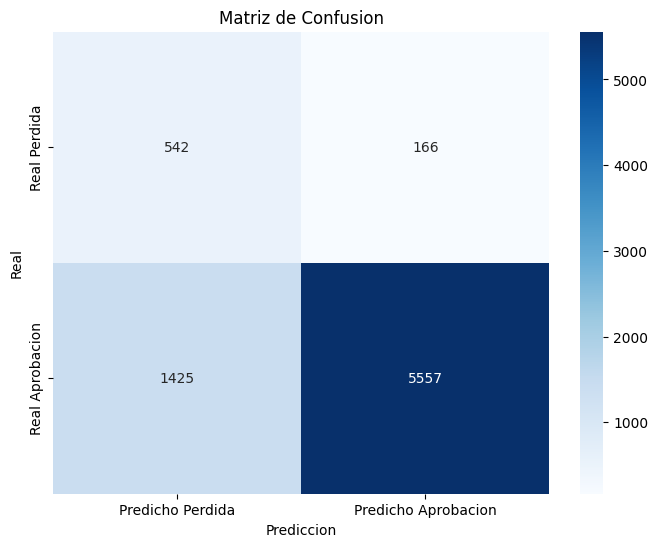

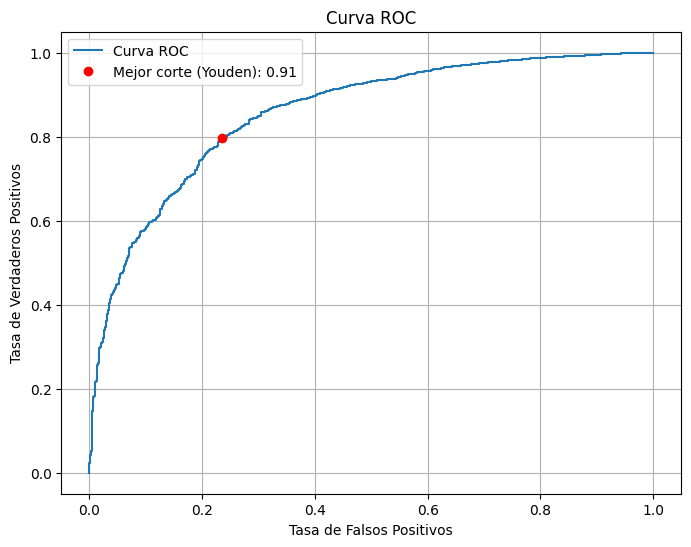


 == Resultados para asignatura:  CAS3020 - COMPETENCIA COMUNICATIVA I == 

No tiene pre requisito
[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.
[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Mas del 80% de los datos no tiene PGA usando las variables del icfes y colegio
[Excluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas seleccionadas: []
Columnas a usar (

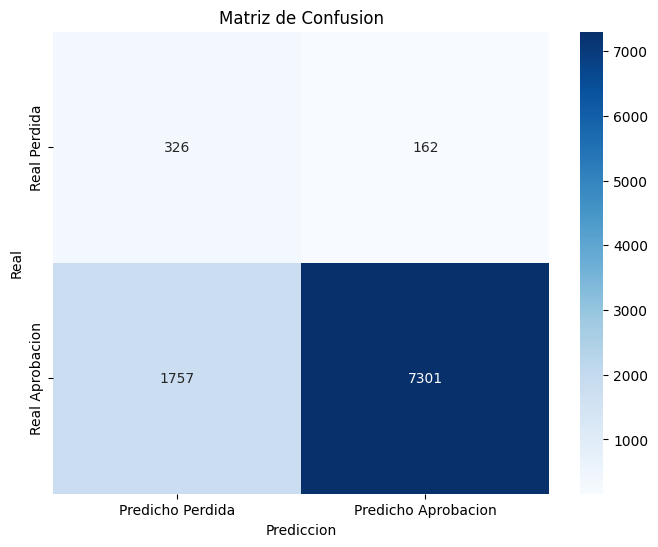

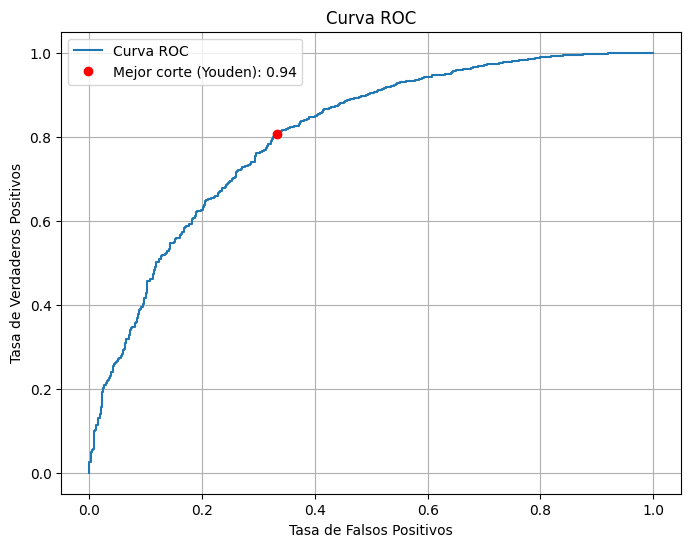


 == Resultados para asignatura:  MAT1031 - ALGEBRA LINEAL == 

No tiene pre requisito
[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.
[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Usar imputacion de ICFES imputar
[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'pga_inicial': 3883 valores imputados usando 'puntaje_saber11' (min=163.0, max=492.0)
[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'promedio_sem_t1': 3951 valores imputados usando 'puntaje_saber11' (mismo escalado)
[Excluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y P

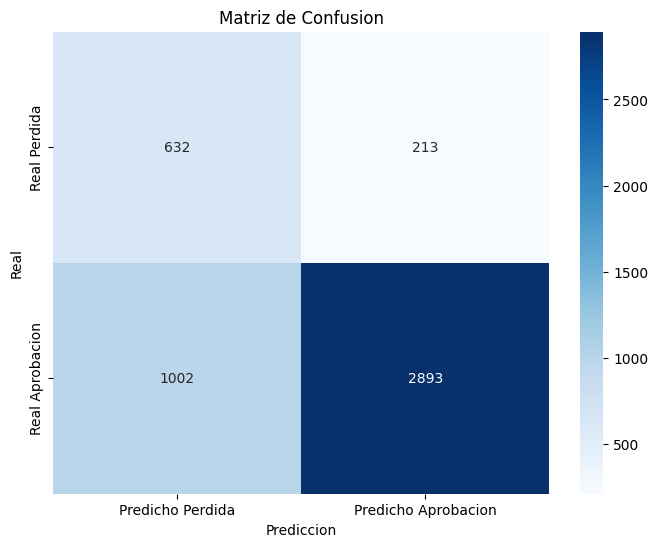

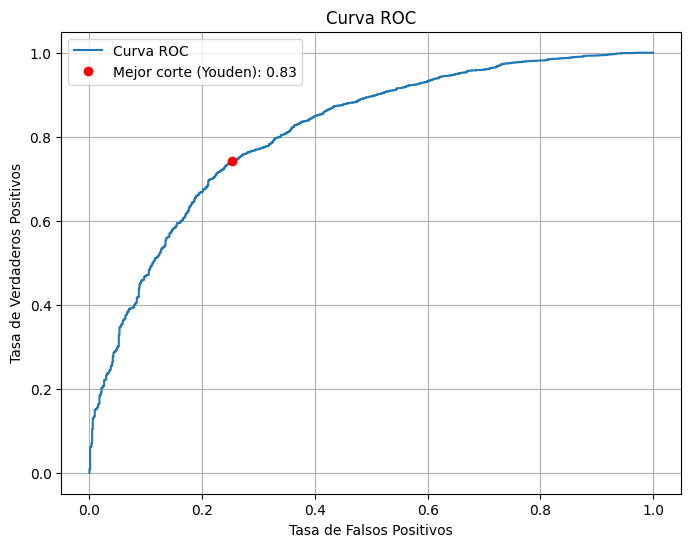


 == Resultados para asignatura:  MAT1101 - CALCULO I == 

No tiene pre requisito
[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.
[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Mas del 80% de los datos no tiene PGA usando las variables del icfes y colegio
[Excluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas seleccionadas: []
Columnas a usar (18): ['repitencia

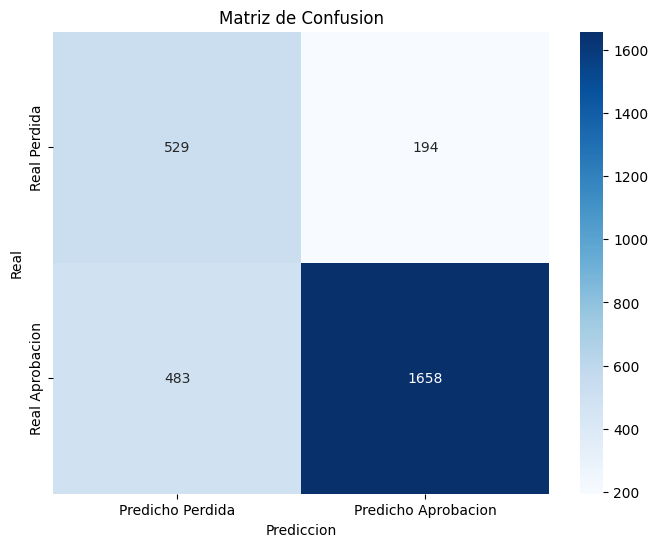

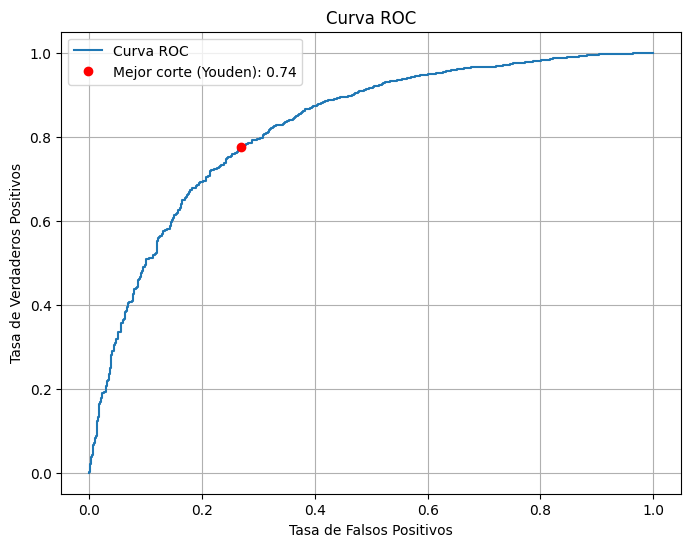


 == Resultados para asignatura:  IST2088 - ALGORITMIA Y PROGRAMACION I == 

No tiene pre requisito
[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.
[ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚ÂÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â] Usar imputacion de ICFES imputar
[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'pga_inicial': 1525 valores imputados usando 'puntaje_saber11' (min=194.0, max=492.0)
[ImputaciÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â³n] Columna 'promedio_sem_t1': 1588 valores imputados usando 'puntaje_saber11' (mismo escalado)
[Excluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% valores vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prer

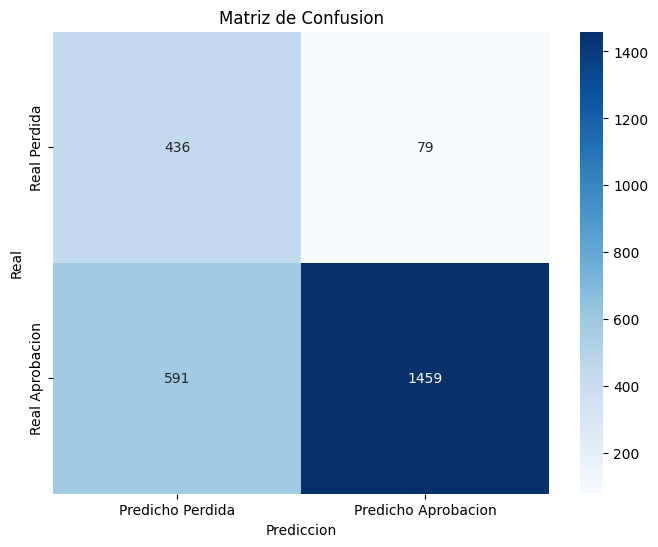

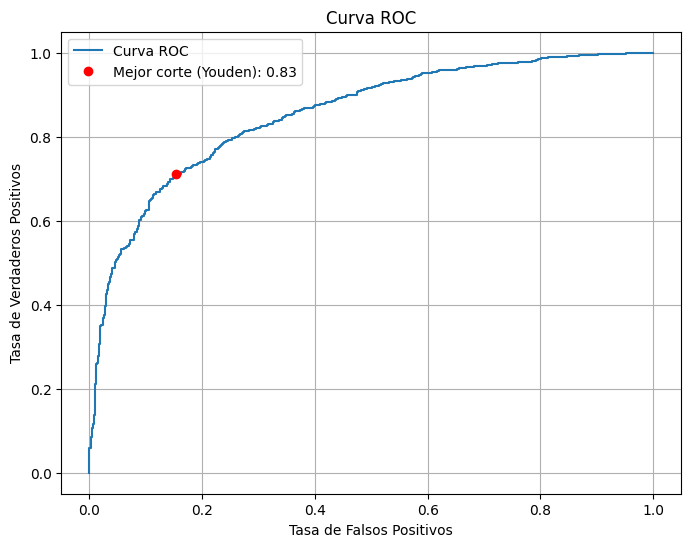


 == Resultados para asignatura:  FIS1023 - FÍSICA MECANICA == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_i_Intentos', 'Prereq_calculo_i_Nota']
Columnas a usar (13): ['repitencia_prof_re

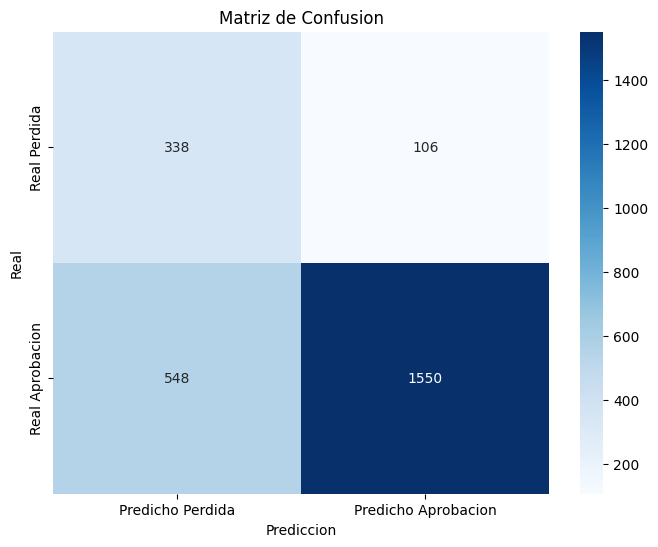

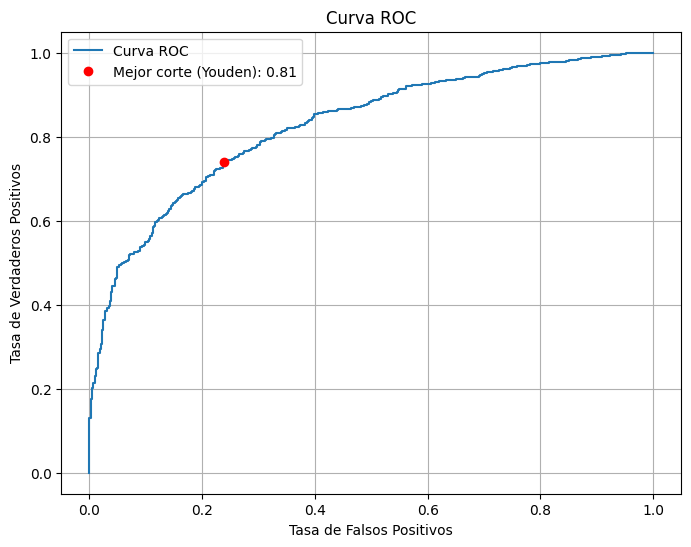


 == Resultados para asignatura:  MAT1111 - CALCULO II == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_i_Intentos', 'Prereq_calculo_i_Nota']
Columnas a usar (13): ['repitencia_prof_ref', '

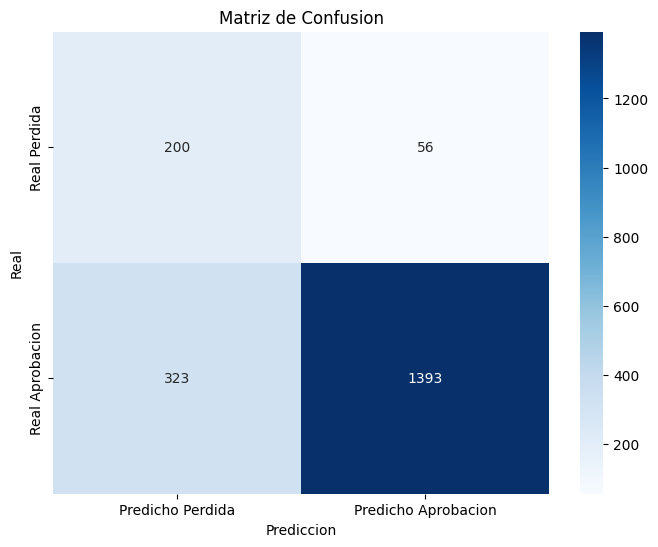

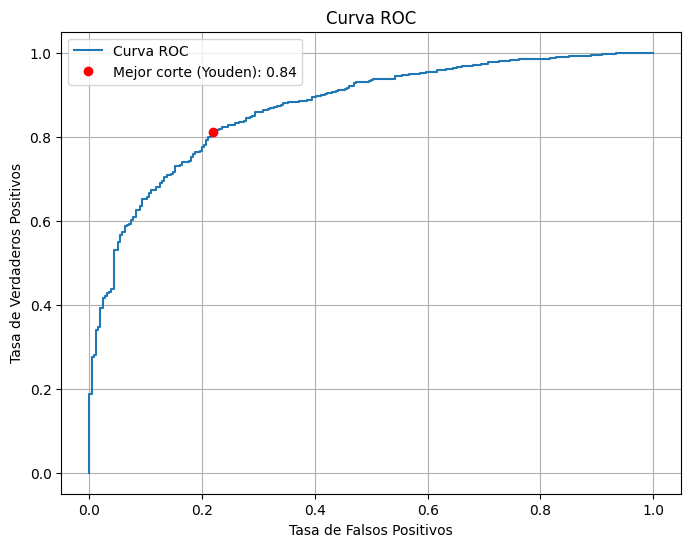


 == Resultados para asignatura:  EST7042 - ANÁLISIS  DE DATOS EN INGEN I == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 95.05% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Column

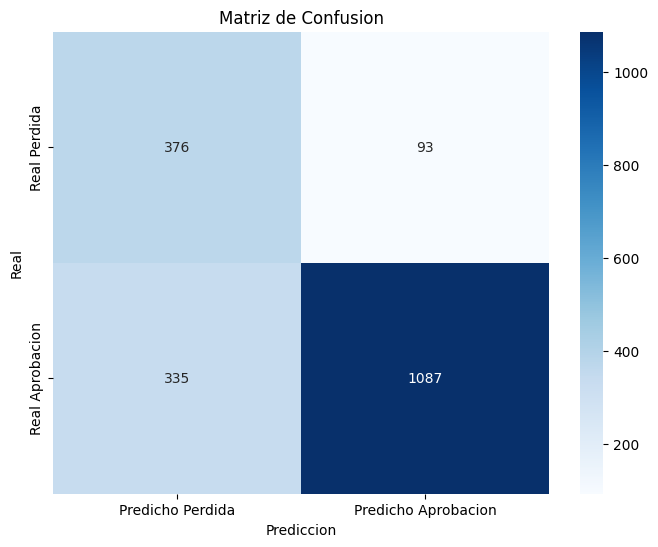

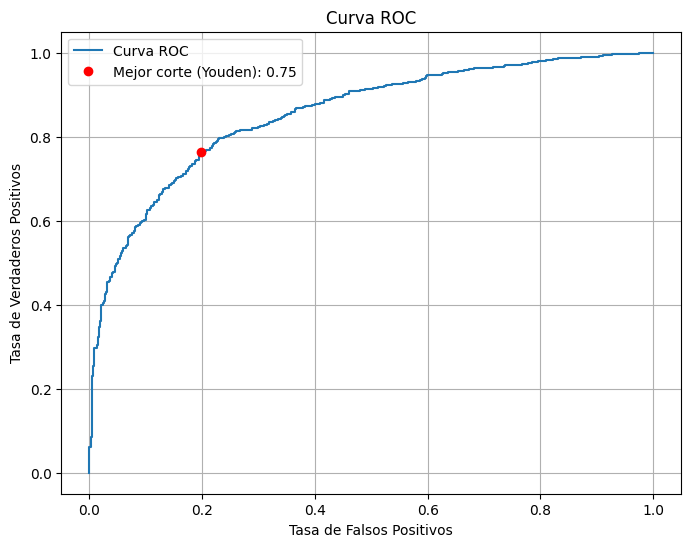


 == Resultados para asignatura:  IST2089 - ALGORITMIA Y PROGRAMACIÓN II == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_algoritmia_y_programacion_i_Intentos', 'Prereq_algoritmia_y_programacion_i_

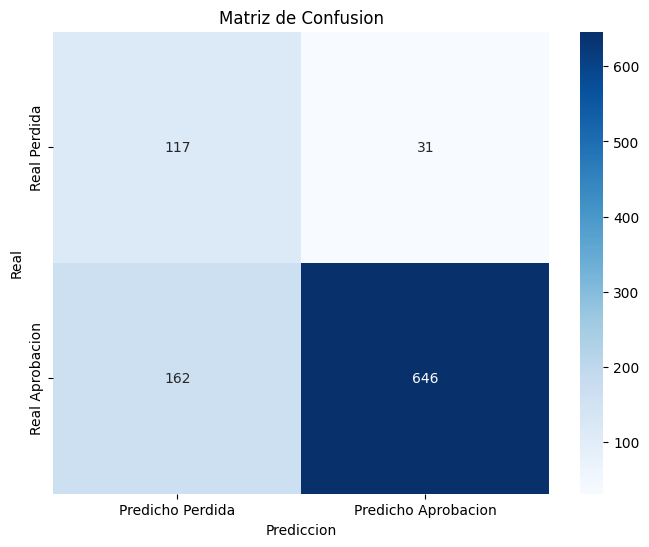

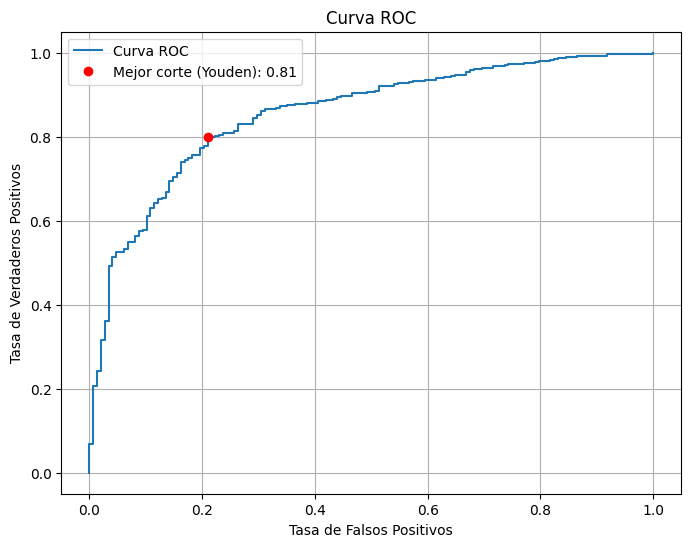


 == Resultados para asignatura:  MAT4011 - ECUACIONES DIFERENCIALES == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 94.33% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nu

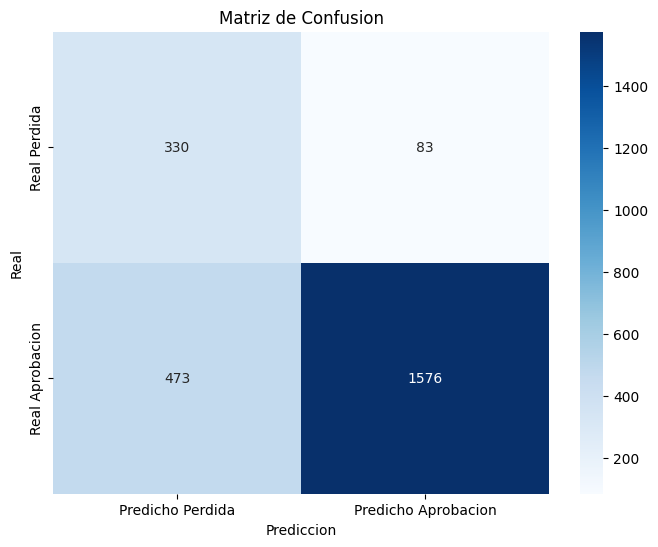

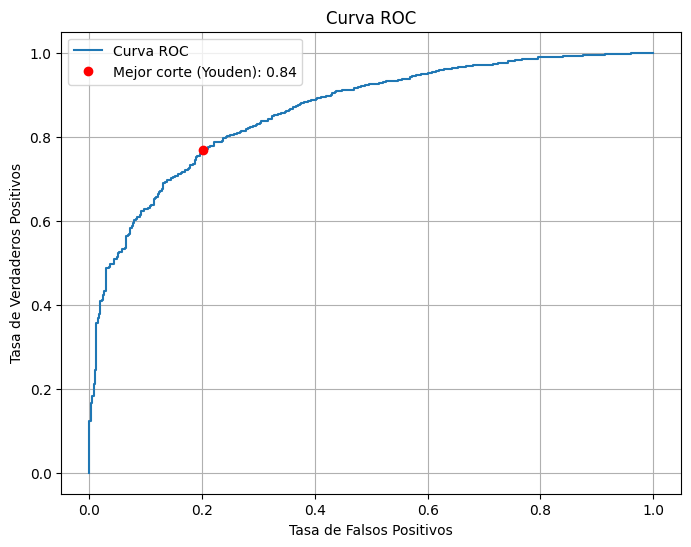


 == Resultados para asignatura:  IBA4032 - ESTÁTICA == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 94.07% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas seleccionad

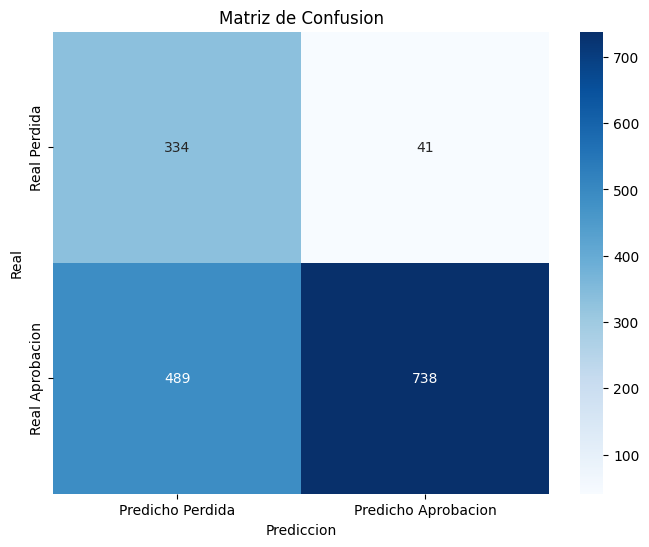

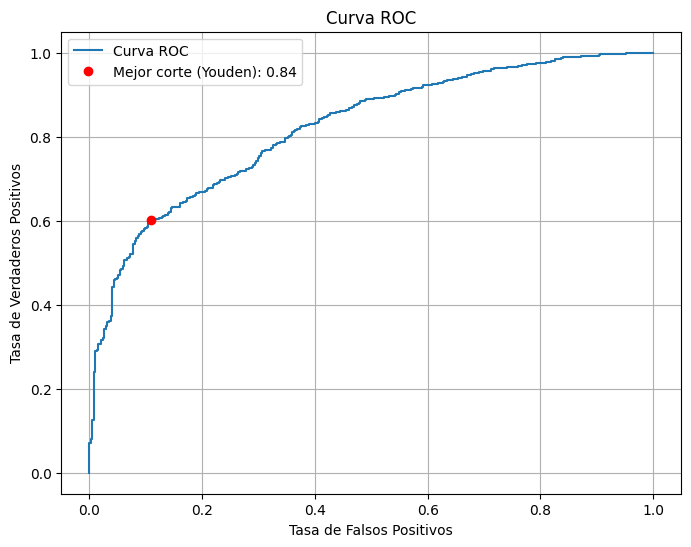


 == Resultados para asignatura:  MAT4258 - CALCULO II (ANEC) == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Intentos']
Columnas a usar (13): ['repite

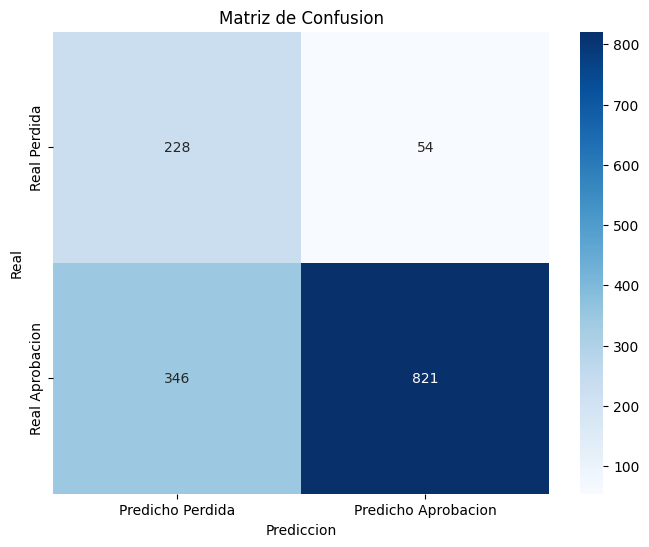

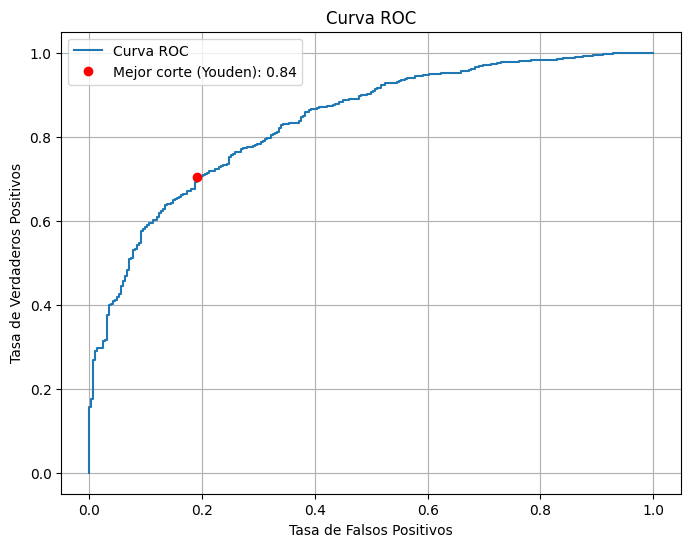


 == Resultados para asignatura:  MAT4260 - CALCULO III (ANEC) == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 93.59% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas s

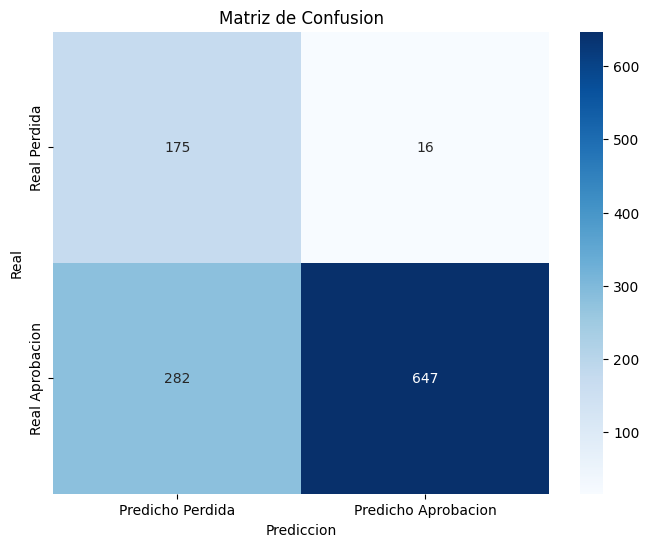

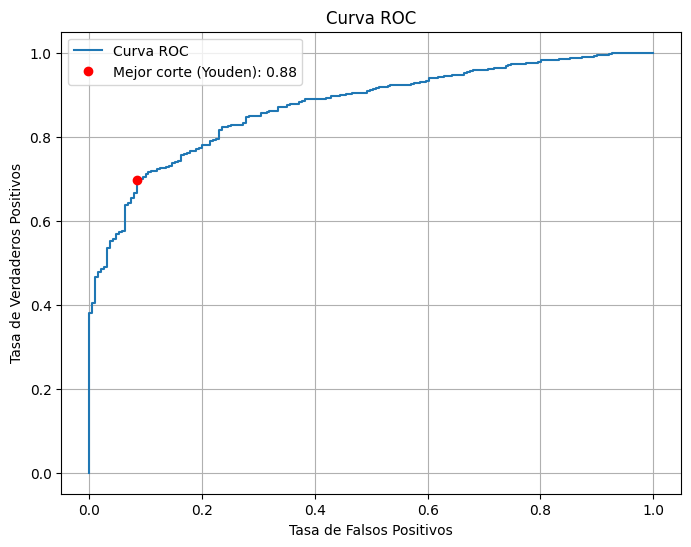


 == Resultados para asignatura:  FIS1033 - FISICA ELECTRICIDAD == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 94.58% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡

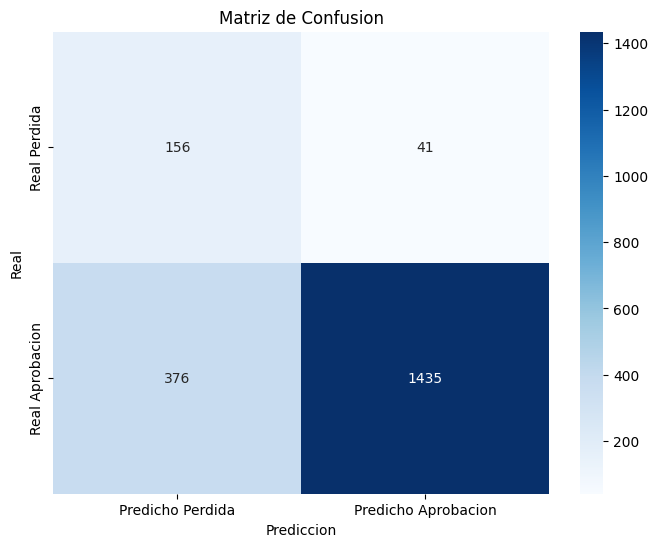

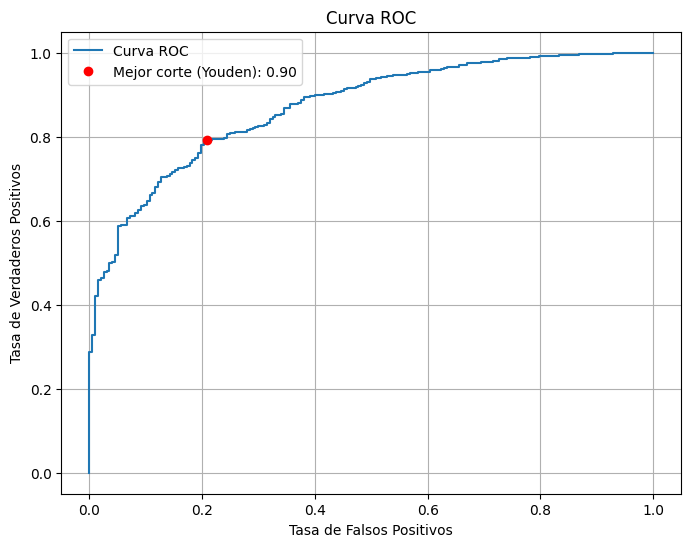


 == Resultados para asignatura:  FIS1043 - FISICA CALOR ONDAS == 

Prerrequisito cumplido
[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.
[Incluido] Prereq_1_Nota y Prereq_1_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 100.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢ 0.00% vÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡lidos (<80%)

Resumen final:
Columnas nuevas 

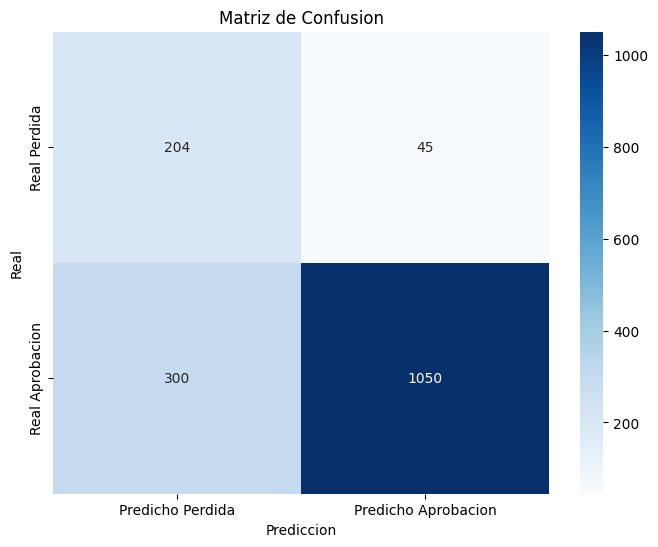

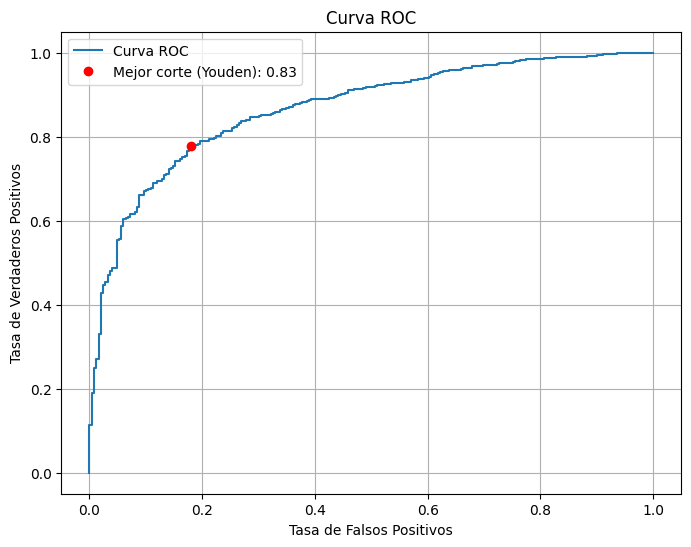

In [120]:
#Correr modelo logit 

col_usar=[]
var_objetivo=""
col_dummies_creadas=[]

for asig in asig_a_usar:
    nombre_asig = df_usar[df_usar["Cod materia curso"] == asig]["Descripcion_Materia"].iloc[0]
    print(f"\n == Resultados para asignatura:  {(asig)} - {(nombre_asig)} == \n")
    df_usar_filtrado = df_usar[df_usar["Cod materia curso"] == asig].copy()
    col_dummies_creadas=[]

    tipo_asig = None
    if 'Observacion_Prerrequisito' in df_usar_filtrado.columns:
        tipo_series = df_usar_filtrado['Observacion_Prerrequisito'].dropna()
        if len(tipo_series) > 0:
            tipo_asig = tipo_series.iloc[0]

    print(tipo_asig)
    if tipo_asig == 'Prerrequisito cumplido':
        print('[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.')
        df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(
            df_usar_filtrado, tiene_prereq=True
        )
        lista_prereq_usar, df_usar_filtrado = columnas_prereq_validas_ext(
            df_usar_filtrado, df_historial_asignaturas_nombres, 0.8
        )
    else:
        print('[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.')
        df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(
            df_usar_filtrado, tiene_prereq=False
        )
        lista_prereq_usar = columnas_prereq_validas(df_usar_filtrado, 0.8)

    col_usar = col_usar + lista_prereq_usar

    print(f"Columnas a usar ({len(col_usar)}): {col_usar} \n  Numero de filas a tener en cuenta: {len(df_usar_filtrado)}")

    cols_to_category = [
        "programa",
        "sexo",
        "procedencia_categoria",
        "profesor_codigo",
        "Tipo_colegio",
        "Tipo_calendario",
    ]

    var_objetivo_clas = 'Retiro_Asignatura_Cat'
    if var_objetivo_clas in df_usar_filtrado.columns:
        df_usar_filtrado[var_objetivo_clas] = pd.to_numeric(df_usar_filtrado[var_objetivo_clas], errors='coerce').fillna(0).astype(int)

    cols_present = [c for c in col_usar if c in df_usar_filtrado.columns]
    if var_objetivo in df_usar_filtrado.columns and var_objetivo not in cols_present:
        cols_present.append(var_objetivo)
    if var_objetivo_clas in df_usar_filtrado.columns and var_objetivo_clas not in cols_present:
        cols_present.append(var_objetivo_clas)

    faltantes = [c for c in col_usar if c not in df_usar_filtrado.columns]
    if faltantes:
        print(f"[Aviso] Algunas columnas de col_usar no existen y se omiten: {faltantes}")

    df_usar_filtrado = df_usar_filtrado[cols_present].copy()
    print(f"[Info] df_usar_filtrado reducido a {df_usar_filtrado.shape[1]} columnas y {len(df_usar_filtrado)} filas")

    df_usar_filtrado, col_usar, num_filas_eliminadas = eliminar_filas_por_columna(df_usar_filtrado, col_usar)
    print(f"[Info] Filas eliminadas por condicion: {num_filas_eliminadas}")

    cols_to_category_present = [c for c in cols_to_category if c in df_usar_filtrado.columns]
    df_usar_filtrado = cambiar_a_category(df_usar_filtrado, cols_to_category_present)

    col_usar = [elemento for elemento in col_usar if elemento not in faltantes]

    if globals().get('variant_modelo_generar', None) == 'fallback':
        if 'eliminar_columnas_prof' in globals():
            df_usar_filtrado = eliminar_columnas_prof(df_usar_filtrado)
        if 'eliminar_columnas_prof_list' in globals():
            col_usar = eliminar_columnas_prof_list(col_usar)
        print(f"[Info] Tipo de modelo: Fallback. Columnas eliminadas por ser del profesor. Nuevas columnas a usar: {col_usar}")


    try:
        df_usar_filtrado_dummies, col_dummies_creadas = aplicar_one_hot(
            df_usar_filtrado, cols_to_category_present, True, 0.03
        )
    except Exception:
        print("se uso umbral de 10% por error de singular matrix")
        df_usar_filtrado_dummies, col_dummies_creadas = aplicar_one_hot(
            df_usar_filtrado, cols_to_category_present, True
        )

    col_usar = col_usar + col_dummies_creadas
    col_usar = [c for c in col_usar if c not in cols_to_category_present]
    col_usar = [c for c in col_usar if c in df_usar_filtrado_dummies.columns]


    df_usar_filtrado_dummies = df_usar_filtrado_dummies.dropna()

    x = df_usar_filtrado_dummies[col_usar]
    x = aplicar_minmax_scaling(x)

    # Revisar singularidad despues de escalar y considerando intercepto de Logit
    x = revisar_singularidad_df(x, incluir_constante=True)
    col_usar = x.columns.tolist()

    x = sm.add_constant(x)
    # Binarizar variable objetivo para Logit: <3 -> 0, >=3 -> 1
    y_raw = pd.to_numeric(df_usar_filtrado_dummies[var_objetivo], errors='coerce')
    y = (y_raw >= 3).astype(int)

    print(f"\n === Resultados del modelo para:  {(asig)} - {(nombre_asig)} === \n")
    df_logit = run_logit_model_general(df_usar_filtrado_dummies, x, y,"_"+asig)

## Modelo con balanceo sintetico desde df_usar_filtrado (antes de dummies) + Logit

[Balanceo] Distribucion original:
resultado_final
1    3168
0     797
Name: count, dtype: int64
[Balanceo] Tecnica: SMOTENC | k_neighbors=5 | cat_cols=6
[Balanceo] Distribucion posterior:
target_logit_bin
1    3168
0    3168
Name: count, dtype: int64
programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
Tipo_colegio             category
Tipo_calendario          category
dtype: object
[OneHot] Columna 'programa' -> eliminada aleatoriamente 'programa_Geología - BARRANQUILLA' para evitar multicolinealidad
[Filtro] Columna 'programa_Administración de Empresas - BARRANQUILLA' no incluida en la lista (solo 0.02% en 1s)
[Filtro] Columna 'programa_Ciencia de Datos - BARRANQUILLA' no incluida en la lista (solo 2.84% en 1s)
[Filtro] Columna 'programa_Economía - BARRANQUILLA' no incluida en la lista (solo 0.05% en 1s)
[Filtro] Columna 'programa_Matemáticas - BARRANQUILLA' no incluida en la lista (solo 1.03% en 1s)
[

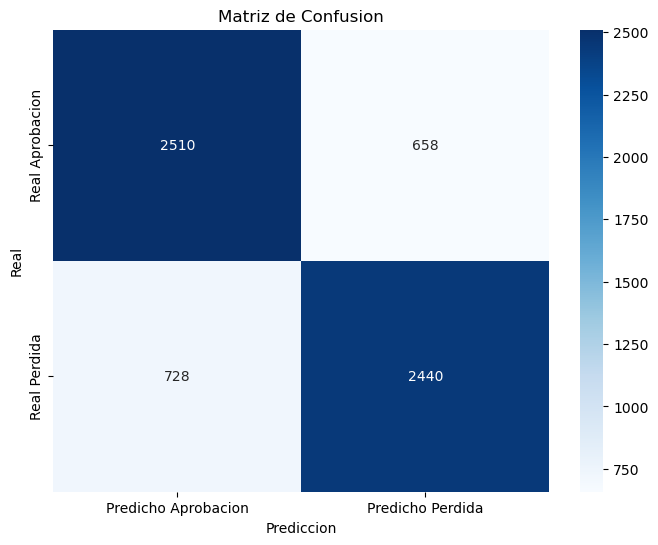

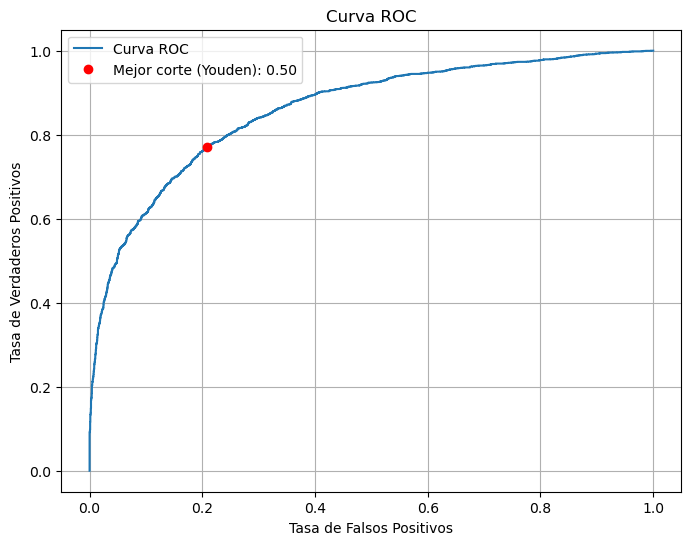

In [101]:
# Balanceo sintetico desde df_usar_filtrado (antes de dummies) + Logit

from imblearn.over_sampling import SMOTENC, RandomOverSampler
from sklearn.preprocessing import OrdinalEncoder

if 'df_usar_filtrado' not in globals() or 'var_objetivo' not in globals():
    raise ValueError("No existe df_usar_filtrado/var_objetivo en memoria. Ejecuta primero la celda '#Correr modelo logit'.")

if len(df_usar_filtrado) == 0:
    raise ValueError("df_usar_filtrado esta vacio.")

# 1) Construir dataset base antes de one-hot
var_objetivo_clas_local = 'Retiro_Asignatura_Cat'
excluir_obj = [var_objetivo]
if var_objetivo_clas_local in df_usar_filtrado.columns:
    excluir_obj.append(var_objetivo_clas_local)

pred_cols_base = [c for c in df_usar_filtrado.columns if c not in excluir_obj]
X_pre = df_usar_filtrado[pred_cols_base].copy()
y_raw = pd.to_numeric(df_usar_filtrado[var_objetivo], errors='coerce')
y_bin = (y_raw >= 3).astype(int)

mask_valid = y_raw.notna()
X_pre = X_pre.loc[mask_valid].copy()
y_bin = y_bin.loc[mask_valid].copy()

if y_bin.nunique() < 2:
    raise ValueError(f"No se puede balancear: variable objetivo binaria con una sola clase ({sorted(y_bin.unique().tolist())}).")

print('[Balanceo] Distribucion original:')
print(y_bin.value_counts(dropna=False))

# 2) Preparar para SMOTENC (categoricas como enteros)
cat_cols = [c for c in X_pre.columns if str(X_pre[c].dtype) in ['object', 'category', 'bool']]
num_cols = [c for c in X_pre.columns if c not in cat_cols]

X_work = X_pre.copy()
for c in num_cols:
    X_work[c] = pd.to_numeric(X_work[c], errors='coerce')
    X_work[c] = X_work[c].fillna(X_work[c].median())
for c in cat_cols:
    X_work[c] = X_work[c].astype(str).fillna('__MISSING__')

enc = None
if len(cat_cols) > 0:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_work[cat_cols] = enc.fit_transform(X_work[cat_cols])

cat_idx = [X_work.columns.get_loc(c) for c in cat_cols]
min_class = int(y_bin.value_counts().min())

if min_class >= 2:
    k_neighbors = min(5, min_class - 1)
    if len(cat_idx) > 0:
        sampler = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=k_neighbors)
        print(f"[Balanceo] Tecnica: SMOTENC | k_neighbors={k_neighbors} | cat_cols={len(cat_cols)}")
    else:
        sampler = RandomOverSampler(random_state=42)
        print("[Balanceo] Sin categoricas para SMOTENC. Fallback a RandomOverSampler.")
else:
    sampler = RandomOverSampler(random_state=42)
    print("[Balanceo] Minoria con <2 casos. Fallback a RandomOverSampler.")

X_res_arr, y_res_arr = sampler.fit_resample(X_work, y_bin)
X_res = pd.DataFrame(X_res_arr, columns=X_work.columns)
y_res = pd.Series(y_res_arr, name='target_logit_bin').astype(int)

# Redondear categoricas sinteticas y devolver etiquetas
if len(cat_cols) > 0:
    for c in cat_cols:
        idx = X_res.columns.get_loc(c)
        n_cat = len(enc.categories_[cat_cols.index(c)])
        X_res[c] = X_res[c].round().clip(0, n_cat - 1)
    X_res[cat_cols] = enc.inverse_transform(X_res[cat_cols])

for c in num_cols:
    X_res[c] = pd.to_numeric(X_res[c], errors='coerce')

print('[Balanceo] Distribucion posterior:')
print(y_res.value_counts(dropna=False))

# 3) Regenerar dummies sobre dataset balanceado (evita pares redundantes tipo sexo_F/sexo_M)
df_balance_pre = X_res.copy()
df_balance_pre[var_objetivo] = y_res.values

cols_to_category_balance = [
    'programa',
    'sexo',
    'procedencia_categoria',
    'profesor_codigo',
    'Tipo_colegio',
    'Tipo_calendario',
]
cols_to_category_balance = [c for c in cols_to_category_balance if c in df_balance_pre.columns]

if len(cols_to_category_balance) > 0:
    df_balance_pre = cambiar_a_category(df_balance_pre, cols_to_category_balance)

df_usar_filtrado_dummies_balanceado, col_dummies_balanceadas = aplicar_one_hot(
    df_balance_pre,
    cols_to_category_balance,
    True
)

pred_cols_balance = [c for c in num_cols if c in df_usar_filtrado_dummies_balanceado.columns] + col_dummies_balanceadas
pred_cols_balance = [c for c in pred_cols_balance if c != var_objetivo]

# Quitar columnas constantes para reducir singularidades
const_cols = [c for c in pred_cols_balance if df_usar_filtrado_dummies_balanceado[c].nunique(dropna=False) <= 1]
if const_cols:
    print(f"[Logit] Columnas constantes removidas: {const_cols}")
pred_cols_balance = [c for c in pred_cols_balance if c not in const_cols]

df_usar_filtrado_dummies_balanceado = df_usar_filtrado_dummies_balanceado.dropna(subset=pred_cols_balance + [var_objetivo]).copy()

x_balanceado = df_usar_filtrado_dummies_balanceado[pred_cols_balance].copy()
x_balanceado = aplicar_minmax_scaling(x_balanceado)
x_balanceado = sm.add_constant(x_balanceado)

y_balanceado = pd.to_numeric(df_usar_filtrado_dummies_balanceado[var_objetivo], errors='coerce').fillna(0).astype(int)

nombre_bal = ("_" + asig + "_balanceado") if 'asig' in globals() else "_balanceado"
df_logit_balanceado = run_logit_model_general(
    df_usar_filtrado_dummies_balanceado,
    x_balanceado,
    y_balanceado,
    nombre_bal
)

## Prueba comp comunicativas 1

[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: Nombre_Programa
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: _ Matricula detalle para analisis.Prof_Codigo
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: _ Matricula detalle para analisis.Sexo
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Columna excluida: _ Matricula detalle para analisis.Procedencia Categoria
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Procesada columna: _ Matricula detalle para analisis.Tipo_Colegio
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â‚¬Å¾Ã‚Â¢Puntos] Procesada columna: Prereq_1_Codigo
[ComasÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€šÃ‚Â Ãƒ

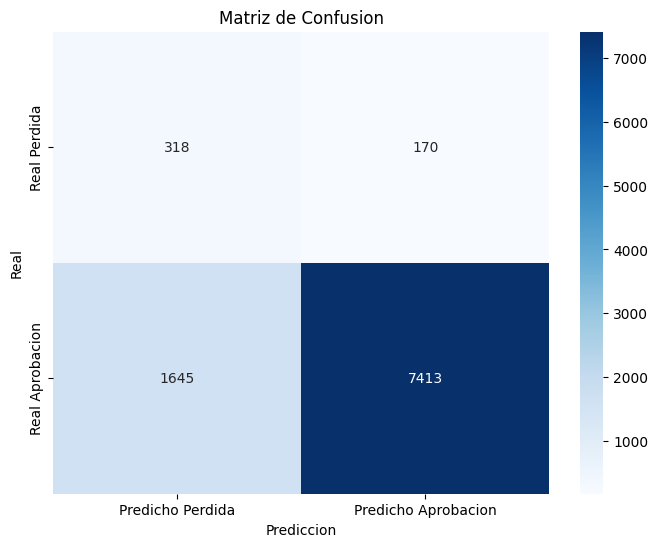

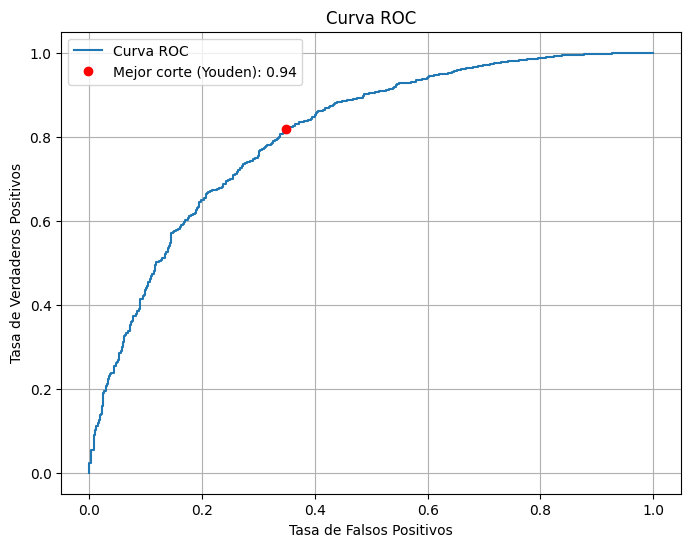

In [116]:
cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

#["FIS1023","MAT1111","FIS1033"]#
#asig_a_usar=#["FIS1023","MAT1111","EST7042","IST2089","MAT4011","IBA4032","MAT4258","MAT4260","FIS1033","FIS1043"]
asig_a_usar=['CAS3020']

df_usar = df_historial[
    ((df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") | (df_historial["Observacion_Prerrequisito"] == "No tiene pre requisito"))&
    (df_historial["Cod materia curso"].isin(asig_a_usar))
].copy()
df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar)

#Correr modelo logit 

col_usar=[]
var_objetivo=""
col_dummies_creadas=[]

for asig in asig_a_usar:
    nombre_asig = df_usar[df_usar["Cod materia curso"] == asig]["Descripcion_Materia"].iloc[0]
    print(f"\n == Resultados para asignatura:  {(asig)} - {(nombre_asig)} == \n")
    df_usar_filtrado = df_usar[df_usar["Cod materia curso"] == asig].copy()
    col_dummies_creadas=[]

    tipo_asig = None
    if 'Observacion_Prerrequisito' in df_usar_filtrado.columns:
        tipo_series = df_usar_filtrado['Observacion_Prerrequisito'].dropna()
        if len(tipo_series) > 0:
            tipo_asig = tipo_series.iloc[0]

    print(tipo_asig)
    if tipo_asig == 'Prerrequisito cumplido':
        print('[Info] Asignatura con prerequisitos. Usando logica CON PRE REQUISITOS.')
        df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(
            df_usar_filtrado, tiene_prereq=True
        )
        lista_prereq_usar, df_usar_filtrado = columnas_prereq_validas_ext(
            df_usar_filtrado, df_historial_asignaturas_nombres, 0.8
        )
    else:
        print('[Info] Asignatura sin prerequisitos. Usando logica SIN PRE REQUISITOS.')
        df_usar_filtrado, col_usar, var_objetivo = renombrar_columnas(
            df_usar_filtrado, tiene_prereq=False
        )
        lista_prereq_usar = columnas_prereq_validas(df_usar_filtrado, 0.8)

    col_usar = col_usar + lista_prereq_usar

    print(f"Columnas a usar ({len(col_usar)}): {col_usar} \n  Numero de filas a tener en cuenta: {len(df_usar_filtrado)}")

    cols_to_category = [
        "programa",
        "sexo",
        "procedencia_categoria",
        "profesor_codigo",
        "Tipo_colegio",
        "Tipo_calendario",
    ]

    var_objetivo_clas = 'Retiro_Asignatura_Cat'
    if var_objetivo_clas in df_usar_filtrado.columns:
        df_usar_filtrado[var_objetivo_clas] = pd.to_numeric(df_usar_filtrado[var_objetivo_clas], errors='coerce').fillna(0).astype(int)

    cols_present = [c for c in col_usar if c in df_usar_filtrado.columns]
    if var_objetivo in df_usar_filtrado.columns and var_objetivo not in cols_present:
        cols_present.append(var_objetivo)
    if var_objetivo_clas in df_usar_filtrado.columns and var_objetivo_clas not in cols_present:
        cols_present.append(var_objetivo_clas)

    faltantes = [c for c in col_usar if c not in df_usar_filtrado.columns]
    if faltantes:
        print(f"[Aviso] Algunas columnas de col_usar no existen y se omiten: {faltantes}")

    df_usar_filtrado = df_usar_filtrado[cols_present].copy()
    print(f"[Info] df_usar_filtrado reducido a {df_usar_filtrado.shape[1]} columnas y {len(df_usar_filtrado)} filas")

    df_usar_filtrado, col_usar, num_filas_eliminadas = eliminar_filas_por_columna(df_usar_filtrado, col_usar)
    print(f"[Info] Filas eliminadas por condicion: {num_filas_eliminadas}")

    cols_to_category_present = [c for c in cols_to_category if c in df_usar_filtrado.columns]
    df_usar_filtrado = cambiar_a_category(df_usar_filtrado, cols_to_category_present)

    col_usar = [elemento for elemento in col_usar if elemento not in faltantes]

    if globals().get('variant_modelo_generar', None) == 'fallback':
        if 'eliminar_columnas_prof' in globals():
            df_usar_filtrado = eliminar_columnas_prof(df_usar_filtrado)
        if 'eliminar_columnas_prof_list' in globals():
            col_usar = eliminar_columnas_prof_list(col_usar)
        print(f"[Info] Tipo de modelo: Fallback. Columnas eliminadas por ser del profesor. Nuevas columnas a usar: {col_usar}")


    try:
        df_usar_filtrado_dummies, col_dummies_creadas = aplicar_one_hot(
            df_usar_filtrado, cols_to_category_present, True, 0.03
        )
    except Exception:
        print("se uso umbral de 10% por error de singular matrix")
        df_usar_filtrado_dummies, col_dummies_creadas = aplicar_one_hot(
            df_usar_filtrado, cols_to_category_present, True
        )

    col_usar = col_usar + col_dummies_creadas
    col_usar = [c for c in col_usar if c not in cols_to_category_present]
    col_usar = [c for c in col_usar if c in df_usar_filtrado_dummies.columns]


    df_usar_filtrado_dummies = df_usar_filtrado_dummies.dropna()

    x = df_usar_filtrado_dummies[col_usar]
    x = aplicar_minmax_scaling(x)

    # Revisar singularidad despues de escalar y considerando intercepto de Logit
    x = revisar_singularidad_df(x, incluir_constante=True)
    col_usar = x.columns.tolist()

    x = sm.add_constant(x)
    # Binarizar variable objetivo para Logit: <3 -> 0, >=3 -> 1
    y_raw = pd.to_numeric(df_usar_filtrado_dummies[var_objetivo], errors='coerce')
    y = (y_raw >= 3).astype(int)

    print(f"\n === Resultados del modelo para:  {(asig)} - {(nombre_asig)} === \n")
    df_logit = run_logit_model_general(df_usar_filtrado_dummies, x, y,"_"+asig)

In [117]:
print(df_usar_filtrado['Tipo_colegio'].value_counts(dropna=False))


print(df_usar_filtrado['Tipo_calendario'].value_counts(dropna=False))

print(df_usar_filtrado['sexo'].value_counts(dropna=False))

Tipo_colegio
Institución Privada    7571
Institución Oficial    1975
Name: count, dtype: int64
Tipo_calendario
Calendario A    7804
Calendario B    1742
I                  0
Name: count, dtype: int64
sexo
M      4785
F      4761
-99       0
N         0
Name: count, dtype: int64
